# Halachic Vesset Pattern Analysis — null-model comparison for clustered longitudinal pattern counts

Companion notebook for the manuscript *Null-Model Choice for Rule-Defined Pattern Counts in
Clustered Longitudinal Sequences: A Case Study of Jewish Halachic Menstrual Anticipation Rules*
(D. Ross; submitted to *Biometrical Journal* as a Case Study).

All pattern-counting code lives in `../scripts/patterns.py` (vectorised implementation verified
against a reference loop implementation). Heavy Monte Carlo work is done by scripts and cached:

| Script | Output | Content |
|---|---|---|
| `scripts/rerun_nulls.py` | `results/null_replicates.npz` | $B = 50{,}000$ replicate count vectors under $H_G$, $H_{iid}$, $H_W$ (seed 17), plus per-woman $H_W$ counts |
| `scripts/sim_validation.py` | `results/sim_validation.npz` | size calibration, power vs AR(1)/persistence alternatives, truncation sensitivity |
| `scripts/postprocess.py` | `results/summary.json` | every number reported in the paper |
| `paper/figures/gen_consort_flow.py` | `fig2_consort_flow` | participant flow diagram (standalone) |

Figures generated here: fig1, fig3, fig4, fig5, fig6, fig7, fig8, fig9, fig10, figA1.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../scripts'))
import numpy as np, pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from itertools import combinations
from patterns import (load_data, weekly_anchor_set, Counter, count_all_loop, perm_within,
                      two_sided_p, holm_adjust, mahalanobis_test, PATTERN_LABELS)

SEED = 17
C_PERM, C_MULTI, C_STRAT, C_OBS = '#2E86AB', '#3DAA5C', '#E07B39', '#C73E1D'
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'serif', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 12, 'axes.labelsize': 10, 'font.size': 9})
FIG = '../paper/figures/'
os.makedirs(FIG, exist_ok=True)
def save(name):
    plt.savefig(f'{FIG}{name}.pdf', bbox_inches='tight'); plt.savefig(f'{FIG}{name}.png', dpi=150, bbox_inches='tight')
    print(f'saved {name}')

## 1. Data

Filtered file derived from the Marquette University "Menstrual Cycle Data" archive (Fehring, 2012), collected in the NFP trial of Fehring et al. (2013). Haflaga convention $H_k = L_k + 1$.
`load_data` asserts that every woman's `CycleNumber` runs 1, 2, …, $n_i$ without gaps, so no pattern window
can bridge an excluded cycle.

In [2]:
data = pd.read_csv('../data/FilteredData.csv', low_memory=False)
H, wid, bounds = load_data('../data/FilteredData.csv')
n_w = len(bounds); n_i = np.array([f - s for s, f in bounds])
L_raw = data['LengthofCycle'].astype(float)
print(f'{n_w} women, {len(H)} cycles; cycles/woman mean {n_i.mean():.1f} SD {n_i.std(ddof=1):.1f} range {n_i.min()}-{n_i.max()}')
print(f'L: mean {L_raw.mean():.2f} SD {L_raw.std():.2f} median {L_raw.median():.1f} skew {L_raw.skew():.2f}; '
      f'H: mean {H.mean():.2f} SD {H.std(ddof=1):.2f}')
print(f'Cycles >= 35 days: {(L_raw>=35).mean()*100:.1f}%')
age = pd.to_numeric(data.groupby('ClientID')['Age'].first(), errors='coerce').dropna()
print(f'Age: {age.min():.0f}-{age.max():.0f}, mean {age.mean():.1f} SD {age.std():.1f} (n={len(age)})')

118 women, 1554 cycles; cycles/woman mean 13.2 SD 6.1 range 5-45
L: mean 29.27 SD 3.86 median 28.5 skew 1.29; H: mean 30.27 SD 3.86
Cycles >= 35 days: 9.6%
Age: 21-43, mean 31.8 SD 5.4 (n=99)


saved fig1_cycle_distribution


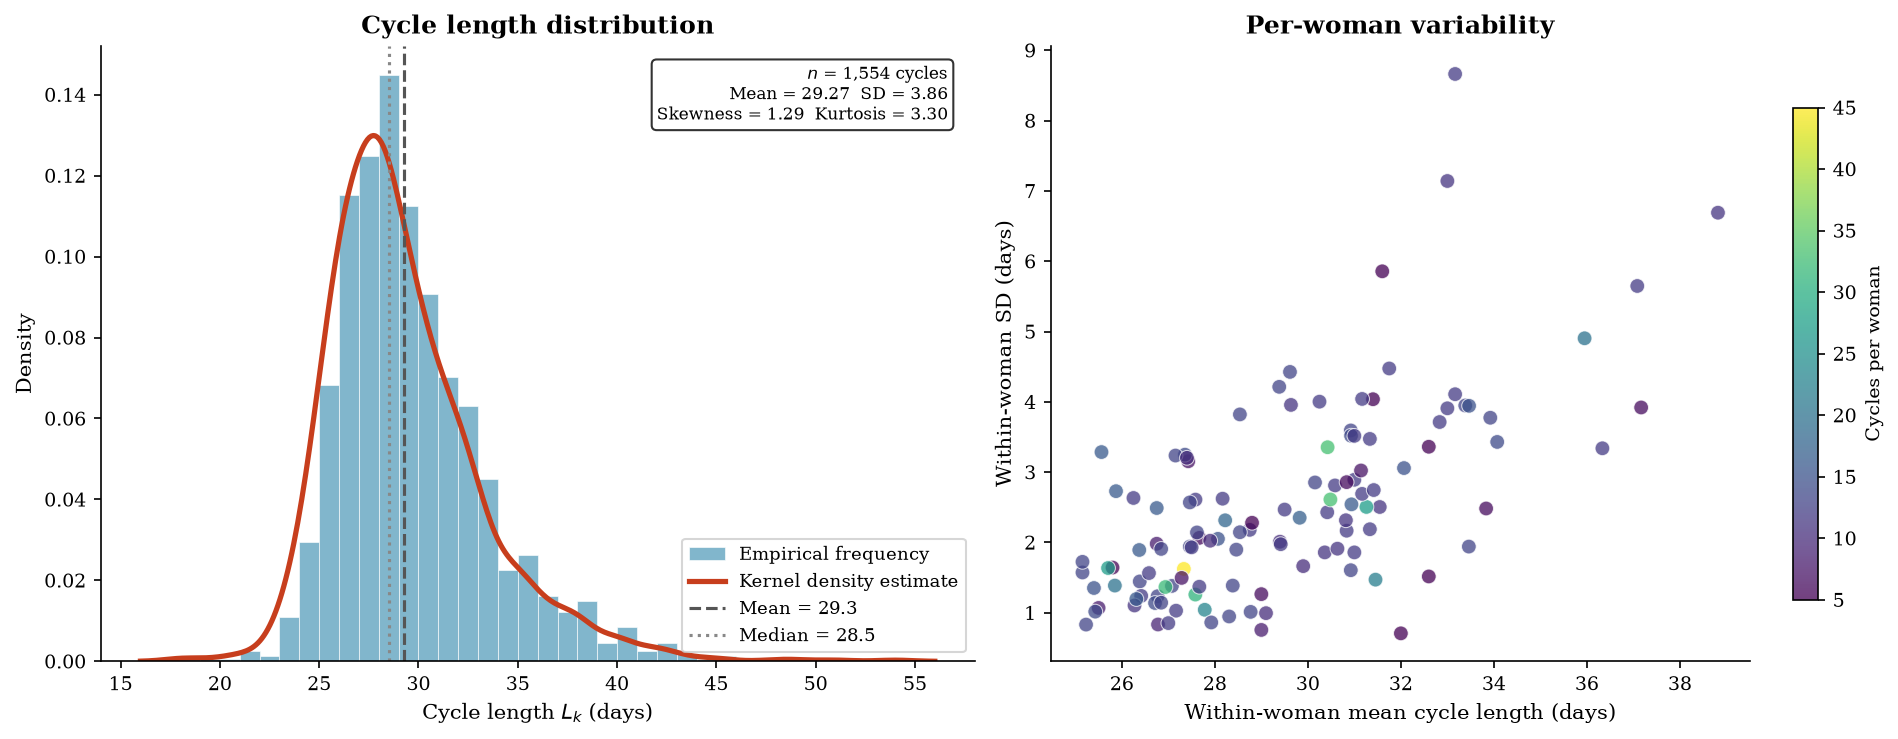

In [3]:
# fig1_cycle_distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.hist(L_raw, bins=range(int(L_raw.min()), int(L_raw.max())+2), color=C_PERM, alpha=0.6, edgecolor='white',
        linewidth=0.5, density=True, label='Empirical frequency')
kde = stats.gaussian_kde(L_raw); xg = np.linspace(L_raw.min()-2, L_raw.max()+2, 400)
ax.plot(xg, kde(xg), color=C_OBS, lw=2.5, label='Kernel density estimate')
ax.axvline(L_raw.mean(), color='#555', lw=1.5, ls='--', label=f'Mean = {L_raw.mean():.1f}')
ax.axvline(L_raw.median(), color='#888', lw=1.5, ls=':', label=f'Median = {L_raw.median():.1f}')
ax.set_xlabel('Cycle length $L_k$ (days)'); ax.set_ylabel('Density'); ax.set_title('Cycle length distribution', fontweight='bold')
ax.legend(fontsize=8.5)
ax.text(0.97, 0.97, f'$n$ = {len(L_raw):,} cycles\nMean = {L_raw.mean():.2f}  SD = {L_raw.std():.2f}\nSkewness = {L_raw.skew():.2f}  Kurtosis = {L_raw.kurtosis():.2f}',
        transform=ax.transAxes, fontsize=8, va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2 = axes[1]
pw_stats = data.groupby('ClientID')['LengthofCycle'].agg(['mean', 'std', 'count'])
sc = ax2.scatter(pw_stats['mean'], pw_stats['std'], c=pw_stats['count'], cmap='viridis', alpha=0.75, s=50, edgecolors='white', linewidth=0.5)
fig.colorbar(sc, ax=ax2, shrink=0.8).set_label('Cycles per woman', fontsize=9)
ax2.set_xlabel('Within-woman mean cycle length (days)'); ax2.set_ylabel('Within-woman SD (days)')
ax2.set_title('Per-woman variability', fontweight='bold')
plt.tight_layout(); save('fig1_cycle_distribution'); plt.show()

saved figA1_heaping_diagnostic


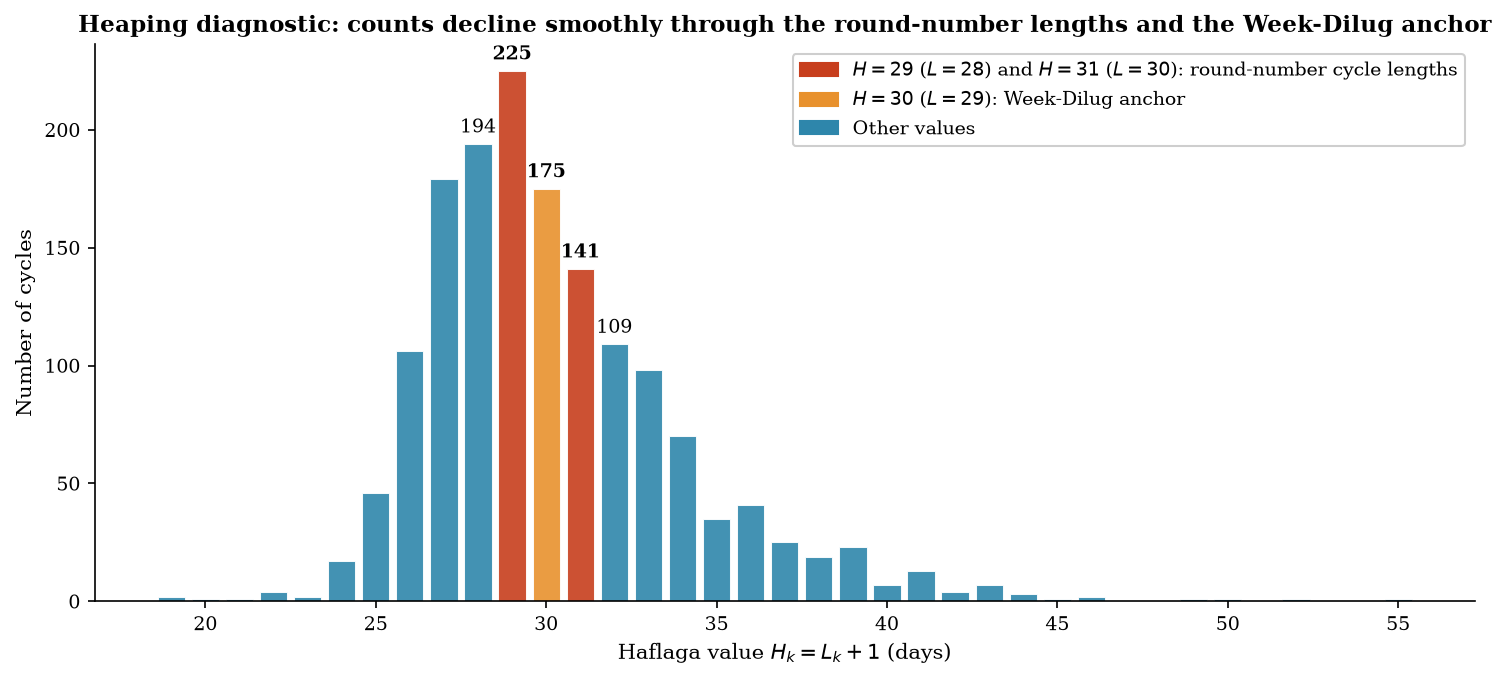

{27: 179, 28: 194, 29: 225, 30: 175, 31: 141, 32: 109}


In [4]:
# figA1_heaping_diagnostic: frequency of each haflaga value H, highlighting round-number cycle lengths
vals, cnts = np.unique(H, return_counts=True)
C_CONCERN, C_ANCHOR = '#C73E1D', '#E8912D'
colors = [C_CONCERN if v in (29, 31) else (C_ANCHOR if v == 30 else C_PERM) for v in vals]
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(vals, cnts, color=colors, alpha=0.9, edgecolor='white', linewidth=0.5)
for v, c in zip(vals, cnts):
    if 28 <= v <= 32:
        ax.text(v, c + 3, str(c), ha='center', va='bottom', fontsize=9, fontweight='bold' if v in (29, 30, 31) else 'normal')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=C_CONCERN, label='$H = 29$ ($L = 28$) and $H = 31$ ($L = 30$): round-number cycle lengths'),
                   Patch(color=C_ANCHOR, label='$H = 30$ ($L = 29$): Week-Dilug anchor'),
                   Patch(color=C_PERM, label='Other values')], loc='upper right', fontsize=9, framealpha=0.95)
ax.set_xlabel('Haflaga value $H_k = L_k + 1$ (days)'); ax.set_ylabel('Number of cycles')
ax.set_title('Heaping diagnostic: counts decline smoothly through the round-number lengths and the Week-Dilug anchor', fontweight='bold', fontsize=11)
plt.tight_layout(); save('figA1_heaping_diagnostic'); plt.show()
print({int(v): int(c) for v, c in zip(vals, cnts) if 27 <= v <= 32})

## 2. Pattern definitions and counting

Halachic literature documents 17 vesset types; 11 need calendar/time-of-day data absent here; 6 are
computable from cycle lengths. The sixth, *Haflaga Chozer Chalila* (a block of ≥ 3 haflaga values repeated
exactly three times in succession; window ≥ 9 cycles), had **zero** observed occurrences; its null
expectation under the three nulls is computed by `scripts/hcc_rule.py` and reported in the SI (Section S3).
The analysed family of five was fixed after the zero count was observed (see paper, Methods).
Formal definitions ($H_k = L_k + 1$):

| Pattern | Condition | Degree | Min. run |
|---|---|---|---|
| Haflaga | $H_k = H_{k-1} = H_{k-2}$ | 0 | 3 |
| Dilug | $H_k - H_{k-1} = H_{k-1} - H_{k-2} = d \neq 0$ | 1 | 3 |
| Week | $H_k = H_{k-1} \in \mathcal{W}$ | 0 | 2 |
| Week-Dilug | $H_k = H_{k-1} = 30$ | 0 | 2 |
| Dilug-in-Dilug | constant non-zero second difference | 2 | 4 |

Counting convention: distinct maximal contiguous runs within a woman; extended runs count once;
resumed runs count again; runs never cross women. The vectorised counter is checked against the
reference loop implementation on the observed data and on random null sequences.

In [5]:
weekly = weekly_anchor_set(H); print('Weekly anchor set W =', sorted(weekly))
C = Counter(wid, weekly)
observed = C.count(H)
assert np.array_equal(observed, count_all_loop(H, bounds, weekly))
rng = np.random.default_rng(0)
for _ in range(300):
    x = perm_within(H, bounds, rng); assert np.array_equal(C.count(x), count_all_loop(x, bounds, weekly))
print('Vectorised and loop counters agree (observed + 300 within-woman permutations).')
print('Observed counts:', dict(zip(PATTERN_LABELS, observed.tolist())))
pw = C.count_by_woman(H, n_w)          # per-woman event counts
flags = (pw > 0).astype(int)
print('Women establishing each pattern at least once:', dict(zip(PATTERN_LABELS, flags.sum(0).tolist())))

Weekly anchor set W = [22, 29, 36, 43, 50]


Vectorised and loop counters agree (observed + 300 within-woman permutations).
Observed counts: {'Haflaga': 26, 'Dilug': 61, 'Week': 32, 'Week-Dilug': 18, 'Dilug-in-Dilug': 27}
Women establishing each pattern at least once: {'Haflaga': 20, 'Dilug': 48, 'Week': 26, 'Week-Dilug': 18, 'Dilug-in-Dilug': 23}


## 3. Null models

* $H_G$ — global permutation of all 1,554 haflaga values (population-level exchangeability).
* $H_{iid}$ — each woman's $n_i$ cycles drawn i.i.d. from the pooled empirical distribution.
* $H_W$ — each woman's sequence permuted uniformly at random **without replacement**: conditional on her
  observed multiset and length, all orderings are equally likely. This destroys within-woman ordering
  (and therefore any serial dependence); it is a conditional Monte Carlo test, not a bootstrap.

Replicates are produced by `scripts/rerun_nulls.py` ($B = 50{,}000$, seed 17, all 1,554 cycles).

In [6]:
R = np.load('../results/null_replicates.npz')
assert int(R['n_cycles']) == len(H) and np.array_equal(R['observed'], observed)
B = int(R['B'])
perm_arr, multi_arr, hw_arr = (R[k].astype(float) for k in ('perm', 'multi', 'within'))
hw_by_woman = R['within_by_woman'].astype(np.int32)
perm_df, multi_df, strat_df = (pd.DataFrame(a, columns=PATTERN_LABELS) for a in (perm_arr, multi_arr, hw_arr))
obs = observed.astype(float)
print(f'Loaded B={B:,} replicates per null (seed {int(R["seed"])}, {int(R["n_cycles"])} cycles).')

Loaded B=50,000 replicates per null (seed 17, 1554 cycles).


In [7]:
# Marginal tests: two-sided Monte Carlo p = 2*min((b+ + 1)/(B+1), (b- + 1)/(B+1)), truncated at 1; Holm across 5
rows = []
for name, arr in [('H_G', perm_arr), ('H_iid', multi_arr), ('H_W', hw_arr)]:
    mu, sd = arr.mean(0), arr.std(0, ddof=1)
    p = np.array([two_sided_p(arr[:, j], obs[j]) for j in range(5)])
    adj = holm_adjust(p)
    for j, l in enumerate(PATTERN_LABELS):
        rows.append(dict(Null=name, Pattern=l, Obs=int(obs[j]), Mean=round(mu[j], 2), SD=round(sd[j], 2),
                         z=round((obs[j]-mu[j])/sd[j], 2), p_two_sided=round(p[j], 4), p_Holm=round(adj[j], 4),
                         n_ge_obs=int((arr[:, j] >= obs[j]).sum())))
summary = pd.DataFrame(rows)
display(summary.style.format({'p_two_sided': '{:.4f}', 'p_Holm': '{:.4f}'}).set_caption('Marginal results (two-sided Monte Carlo p-values; Holm across the five patterns)'))
g, i_ = summary[summary.Null == 'H_G'].p_two_sided.values, summary[summary.Null == 'H_iid'].p_two_sided.values
print('max |p_G - p_iid| =', np.abs(g - i_).max().round(3))

,Null,Pattern,Obs,Mean,SD,z,p_two_sided,p_Holm,n_ge_obs
0,H_G,Haflaga,26,11.310000,3.270000,4.500000,0.0002,0.0010,4
1,H_G,Dilug,61,48.920000,6.570000,1.840000,0.0850,0.3400,2124
2,H_G,Week,32,27.020000,4.010000,1.240000,0.2647,0.7941,6617
3,H_G,Week-Dilug,18,16.250000,3.250000,0.540000,0.6882,1.0000,17204
4,H_G,Dilug-in-Dilug,27,27.170000,5.000000,-0.030000,1.0000,1.0000,27179
5,H_iid,Haflaga,26,11.480000,3.310000,4.390000,0.0003,0.0014,6
6,H_iid,Dilug,61,48.860000,6.590000,1.840000,0.0820,0.3282,2050
7,H_iid,Week,32,27.090000,5.000000,0.980000,0.3732,1.0000,9328
8,H_iid,Week-Dilug,18,16.350000,3.940000,0.420000,0.7428,1.0000,18569
9,H_iid,Dilug-in-Dilug,27,27.300000,5.070000,-0.060000,1.0000,1.0000,27637


max |p_G - p_iid| = 0.108


saved fig3_null_distributions


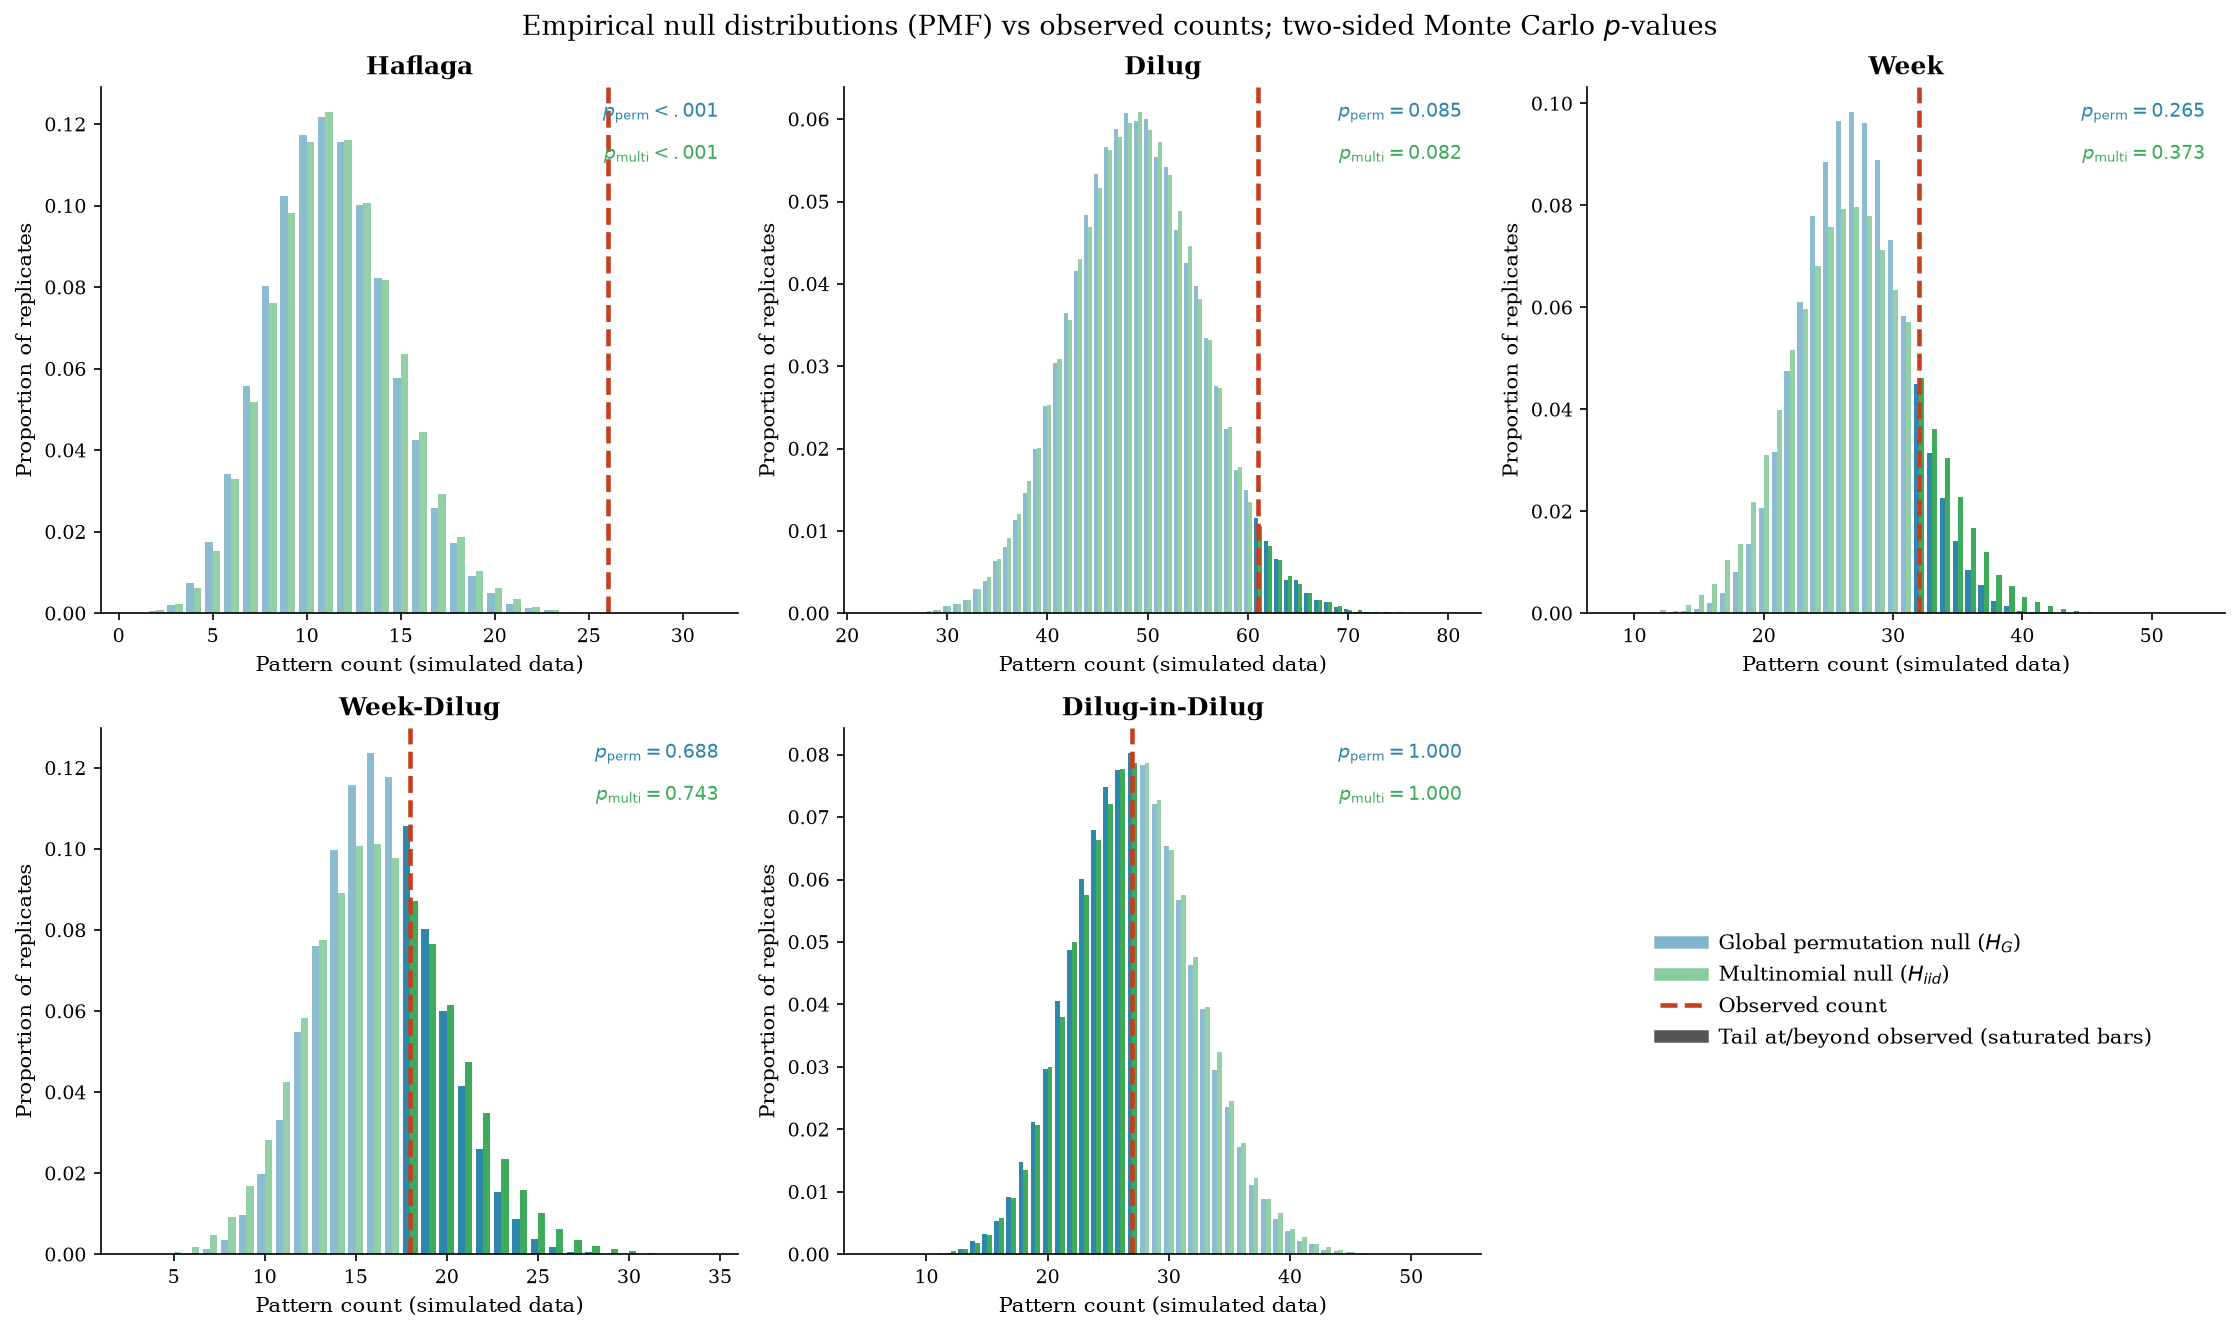

In [8]:
# fig3_null_distributions: empirical PMFs under H_G and H_iid with two-sided p-values
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()
for j, label in enumerate(PATTERN_LABELS):
    ax = axes[j]; o = obs[j]
    lo_v = int(min(perm_arr[:, j].min(), multi_arr[:, j].min())); hi_v = int(max(perm_arr[:, j].max(), multi_arr[:, j].max()))
    xs = np.arange(lo_v, hi_v + 1)
    for k, (arr, color, nm) in enumerate([(perm_arr, C_PERM, 'perm'), (multi_arr, C_MULTI, 'multi')]):
        pmf = np.array([(arr[:, j] == v).mean() for v in xs])
        mu = arr[:, j].mean()
        tail = xs >= o if o >= mu else xs <= o          # tail on the observed side (the smaller tail)
        off = -0.2 if k == 0 else 0.2
        ax.bar(xs + off, pmf, width=0.4, color=color, alpha=0.55, edgecolor='none')
        ax.bar(xs[tail] + off, pmf[tail], width=0.4, color=color, alpha=1.0, edgecolor='none')
        p2 = two_sided_p(arr[:, j], o)
        ax.text(0.97, 0.97 - 0.08*k, f'$p_{{\\mathrm{{{nm}}}}} = {p2:.3f}$' if p2 >= .001 else f'$p_{{\\mathrm{{{nm}}}}} < .001$',
                transform=ax.transAxes, ha='right', va='top', fontsize=9, color=color)
    ax.axvline(o, color=C_OBS, lw=2.2, ls='--')
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('Pattern count (simulated data)'); ax.set_ylabel('Proportion of replicates')
leg = [Line2D([0], [0], color=C_PERM, lw=6, alpha=0.6, label='Global permutation null ($H_G$)'),
       Line2D([0], [0], color=C_MULTI, lw=6, alpha=0.6, label='Multinomial null ($H_{iid}$)'),
       Line2D([0], [0], color=C_OBS, lw=2.2, ls='--', label='Observed count'),
       Line2D([0], [0], color='#555', lw=6, label='Tail at/beyond observed (saturated bars)')]
axes[5].legend(handles=leg, loc='center', fontsize=10, frameon=False); axes[5].axis('off')
fig.suptitle('Empirical null distributions (PMF) vs observed counts; two-sided Monte Carlo $p$-values', fontsize=13)
plt.tight_layout(); save('fig3_null_distributions'); plt.show()

saved fig4_zscores


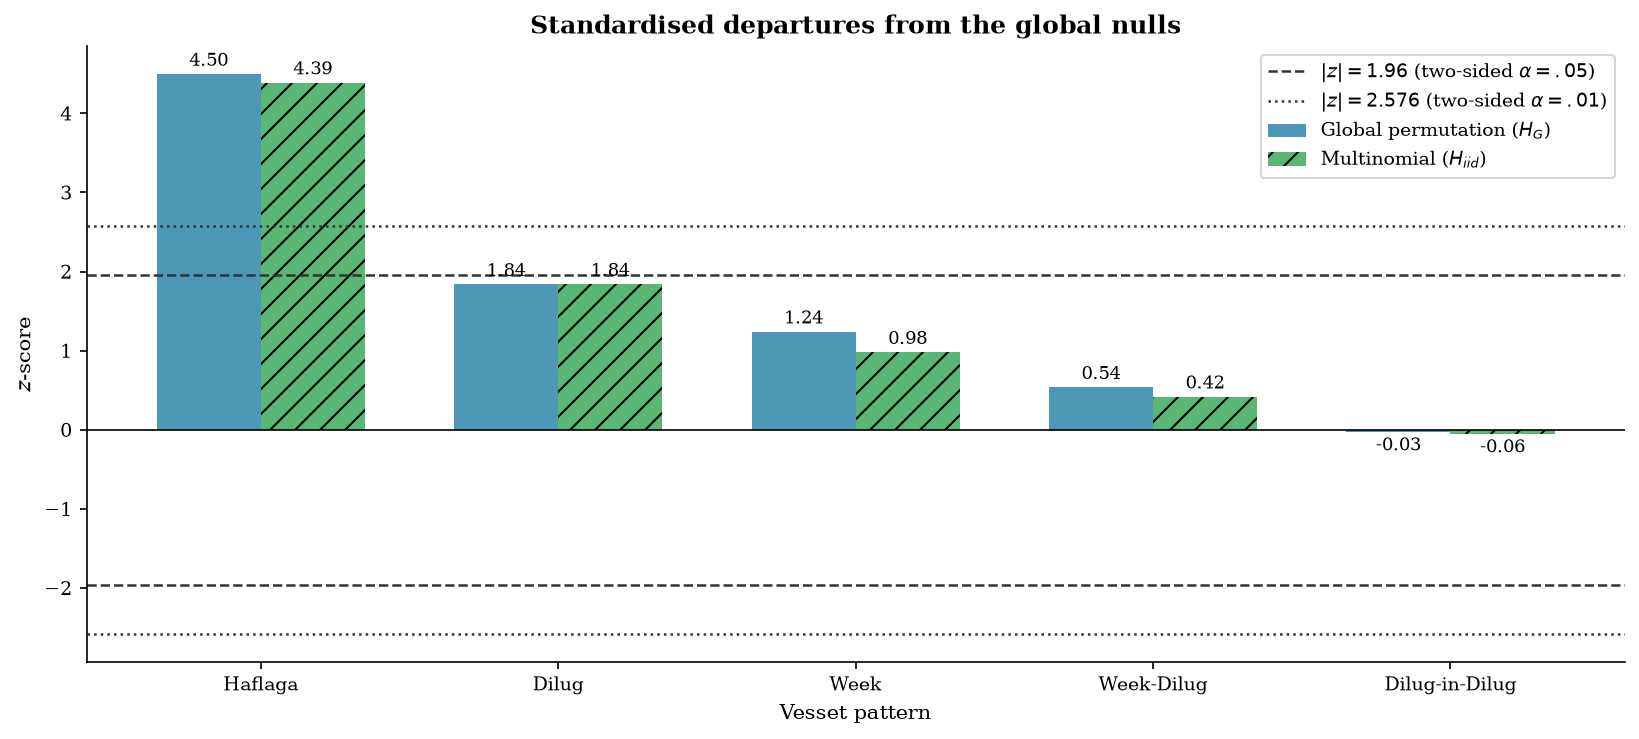

z (H_G): [ 4.5   1.84  1.24  0.54 -0.03]  z (H_iid): [ 4.39  1.84  0.98  0.42 -0.06]


In [9]:
# fig4_zscores
pz = (obs - perm_arr.mean(0)) / perm_arr.std(0, ddof=1); mz = (obs - multi_arr.mean(0)) / multi_arr.std(0, ddof=1)
xp = np.arange(5); w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(xp - w/2, pz, w, label='Global permutation ($H_G$)', color=C_PERM, alpha=0.85)
b2 = ax.bar(xp + w/2, mz, w, label='Multinomial ($H_{iid}$)', color=C_MULTI, alpha=0.85, hatch='//')
for y, ls, lab in [(1.96, '--', '$|z| = 1.96$ (two-sided $\\alpha=.05$)'), (2.576, ':', '$|z| = 2.576$ (two-sided $\\alpha=.01$)')]:
    ax.axhline(y, color='#333', lw=1.2, ls=ls, label=lab); ax.axhline(-y, color='#333', lw=1.2, ls=ls)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xp); ax.set_xticklabels(PATTERN_LABELS); ax.set_ylabel('$z$-score'); ax.set_xlabel('Vesset pattern')
ax.set_title('Standardised departures from the global nulls', fontweight='bold'); ax.legend(fontsize=9)
for bar in [*b1, *b2]:
    h = bar.get_height(); ax.text(bar.get_x() + bar.get_width()/2, h + 0.05 if h >= 0 else h - 0.28, f'{h:.2f}', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout(); save('fig4_zscores'); plt.show()
print('z (H_G):', pz.round(2), ' z (H_iid):', mz.round(2))

saved fig5_cdfs


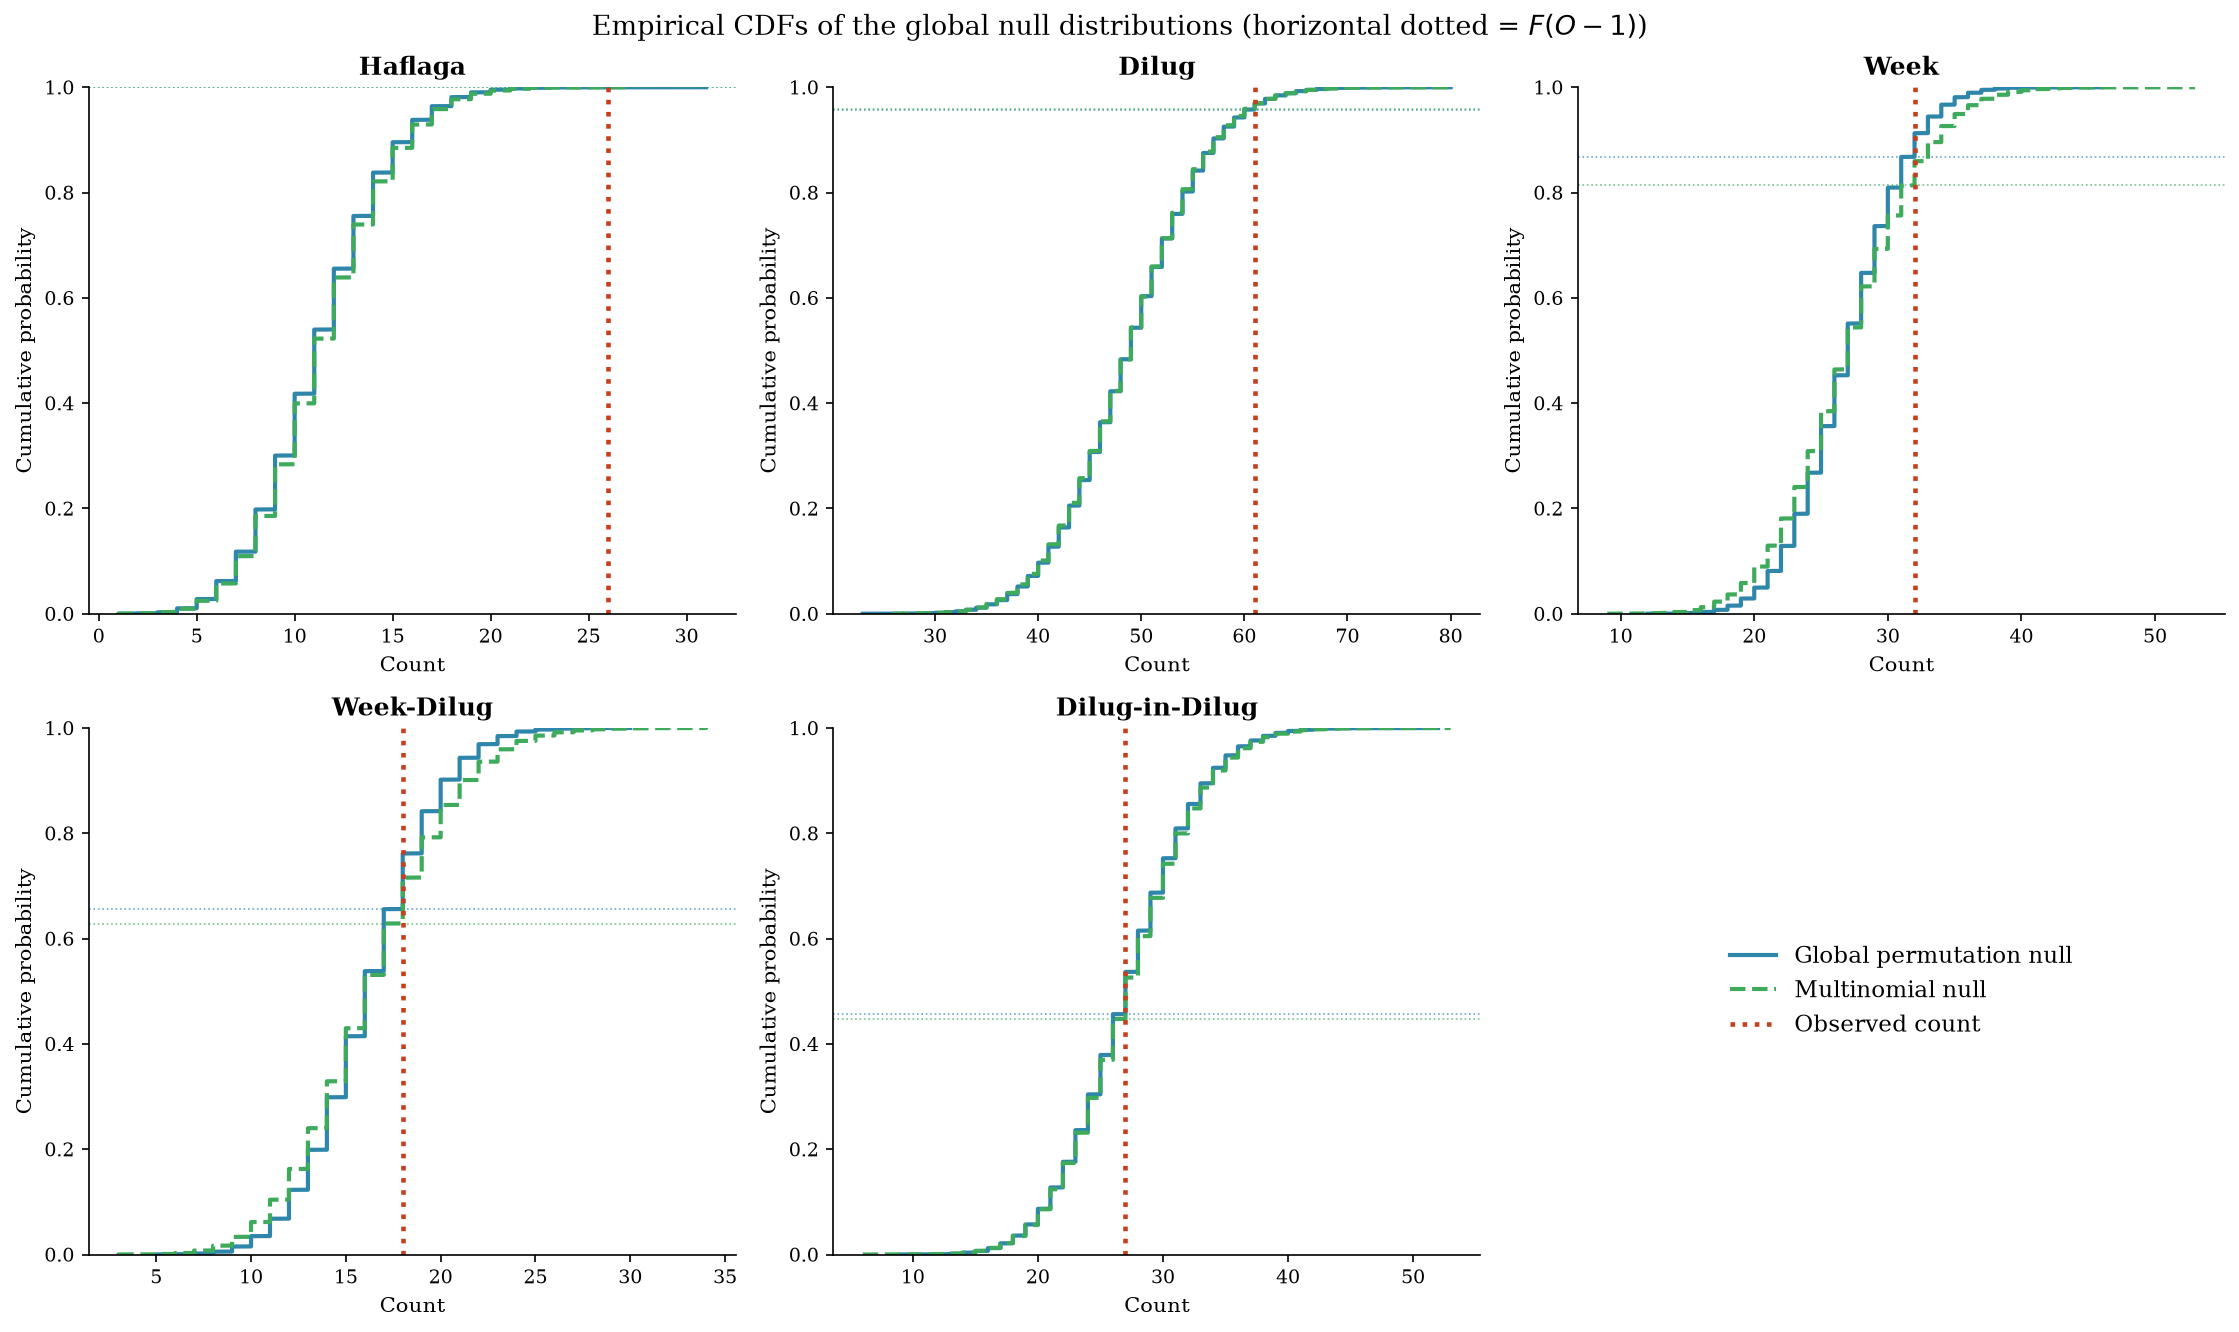

In [10]:
# fig5_cdfs
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()
for j, label in enumerate(PATTERN_LABELS):
    ax = axes[j]; o = obs[j]
    for arr, color, ls in [(perm_arr, C_PERM, '-'), (multi_arr, C_MULTI, '--')]:
        v = np.sort(arr[:, j]); cdf = np.arange(1, len(v)+1) / len(v)
        ax.plot(v, cdf, color=color, lw=2, ls=ls)
        ax.axhline((arr[:, j] < o).mean(), color=color, lw=0.8, ls=':', alpha=0.7)
    ax.axvline(o, color=C_OBS, lw=2.2, ls=':')
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('Count'); ax.set_ylabel('Cumulative probability'); ax.set_ylim(0, 1)
leg = [Line2D([0], [0], color=C_PERM, lw=2, label='Global permutation null'), Line2D([0], [0], color=C_MULTI, lw=2, ls='--', label='Multinomial null'),
       Line2D([0], [0], color=C_OBS, lw=2.2, ls=':', label='Observed count')]
axes[5].legend(handles=leg, loc='center', fontsize=11, frameon=False); axes[5].axis('off')
fig.suptitle('Empirical CDFs of the global null distributions (horizontal dotted = $F(O-1)$)', fontsize=13)
plt.tight_layout(); save('fig5_cdfs'); plt.show()

## 4. Joint Mahalanobis test

$D_M = \sqrt{(\mathbf O - \hat{\boldsymbol\mu})^\top \hat\Sigma^{-1} (\mathbf O - \hat{\boldsymbol\mu})}$ with
$\hat{\boldsymbol\mu}, \hat\Sigma$ the mean and covariance of the null replicate count vectors; $p$ = fraction of
replicates whose $D_M$ is at least the observed value, with the $(b+1)/(B+1)$ convention. As a check on the use of
the same replicates for $\hat\Sigma$ and for the reference distribution, the split-batch variant estimates
$\hat{\boldsymbol\mu}, \hat\Sigma$ from the first 25,000 replicates and the reference distribution from the last 25,000.

In [11]:
joint = {}
for name, arr in [('H_G', perm_arr), ('H_iid', multi_arr), ('H_W', hw_arr)]:
    DM, p, dm_null, Sig = mahalanobis_test(arr, obs)
    DMs, ps, _, _ = mahalanobis_test(arr[B//2:], obs, ref=arr[:B//2])
    DM3, p3, dm3, _ = mahalanobis_test(arr[:, [0, 3, 4]], obs[[0, 3, 4]])
    corr = np.corrcoef(arr.T); np.fill_diagonal(corr, 0)
    joint[name] = dict(DM=DM, p=p, n_exceed=int((dm_null >= DM).sum()), DM_split=DMs, p_split=ps, DM3=DM3, p3=p3,
                       n_exceed3=int((dm3 >= DM3).sum()), cond=np.linalg.cond(Sig), max_abs_r=np.abs(corr).max(), dm_null=dm_null)
    print(f"{name:<6} 5-pattern D_M={DM:.2f} p={p:.4f} ({joint[name]['n_exceed']} of {B} >= obs) | split-batch D_M={DMs:.2f} p={ps:.4f} | "
          f"3-pattern D_M={DM3:.2f} p={p3:.4f} | cond={joint[name]['cond']:.1f} max|r|={joint[name]['max_abs_r']:.2f}")

H_G    5-pattern D_M=5.08 p=0.0001 (6 of 50000 >= obs) | split-batch D_M=5.07 p=0.0002 | 3-pattern D_M=4.50 p=0.0002 | cond=4.6 max|r|=0.12
H_iid  5-pattern D_M=4.87 p=0.0004 (17 of 50000 >= obs) | split-batch D_M=4.87 p=0.0003 | 3-pattern D_M=4.39 p=0.0005 | cond=4.4 max|r|=0.16
H_W    5-pattern D_M=2.93 p=0.1257 (6285 of 50000 >= obs) | split-batch D_M=2.95 p=0.1186 | 3-pattern D_M=2.68 p=0.0666 | cond=5.4 max|r|=0.14


saved fig7_dm_nulldist


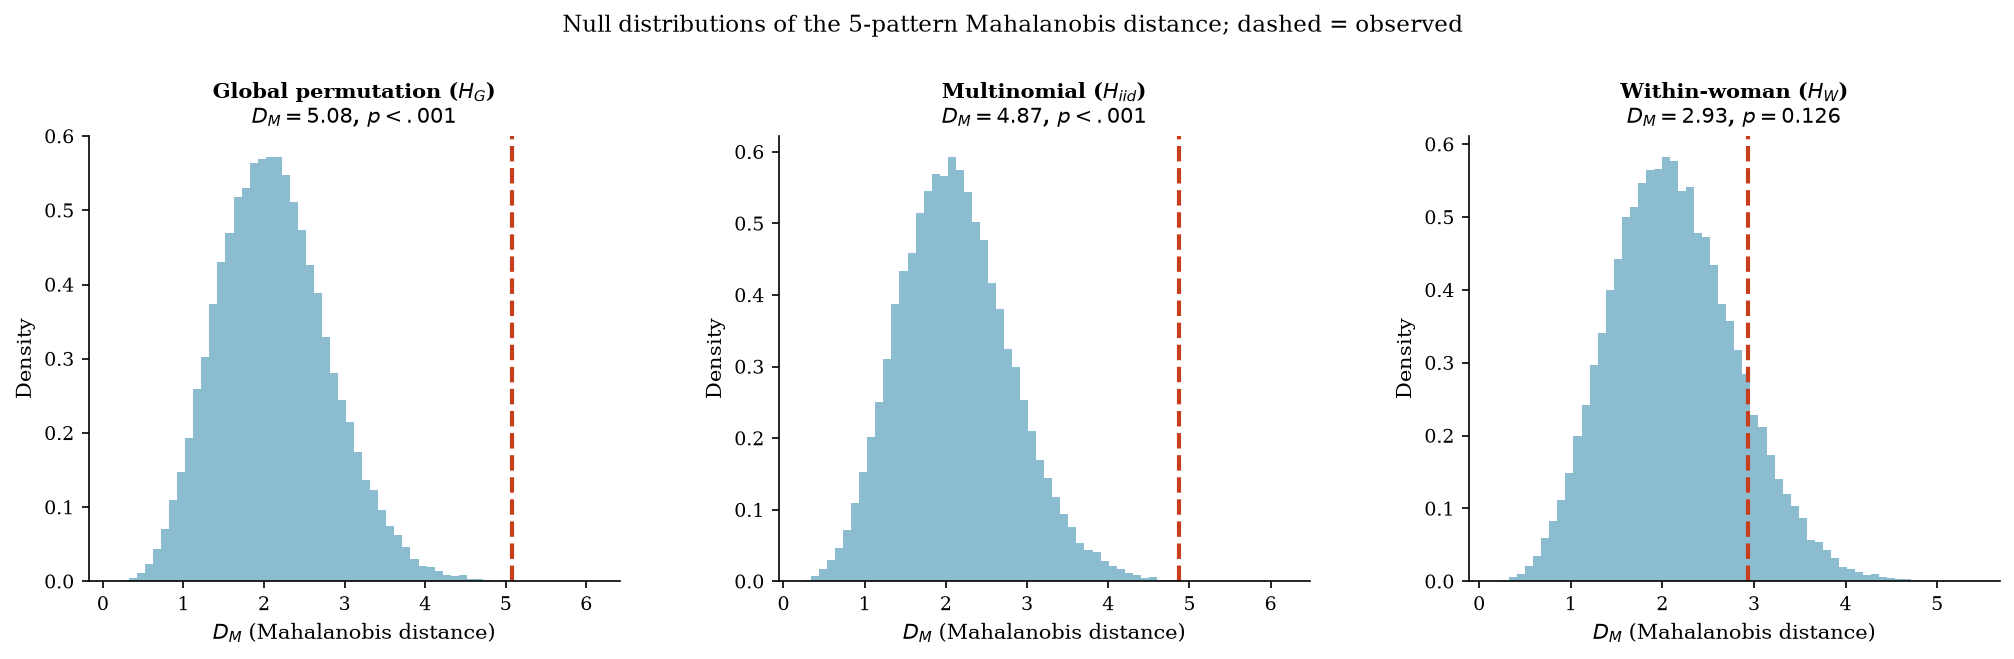

In [12]:
# fig7_dm_nulldist
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5)); fig.subplots_adjust(left=0.06, right=0.97, bottom=0.14, top=0.80, wspace=0.30)
for ax, (name, title) in zip(axes, [('H_G', 'Global permutation ($H_G$)'), ('H_iid', 'Multinomial ($H_{iid}$)'), ('H_W', 'Within-woman ($H_W$)')]):
    d = joint[name]; ax.hist(d['dm_null'], bins=60, color=C_PERM, alpha=0.55, edgecolor='none', density=True)
    ax.axvline(d['DM'], color=C_OBS, lw=2, ls='--')
    p_str = '$p < .001$' if d['p'] < .001 else f"$p = {d['p']:.3f}$"
    ax.set_title(f"{title}\n$D_M = {d['DM']:.2f}$, {p_str}", fontsize=10, fontweight='bold')
    ax.set_xlabel('$D_M$ (Mahalanobis distance)'); ax.set_ylabel('Density')
fig.suptitle('Null distributions of the 5-pattern Mahalanobis distance; dashed = observed', fontsize=11)
save('fig7_dm_nulldist'); plt.show()

saved fig6_stratified_comparison


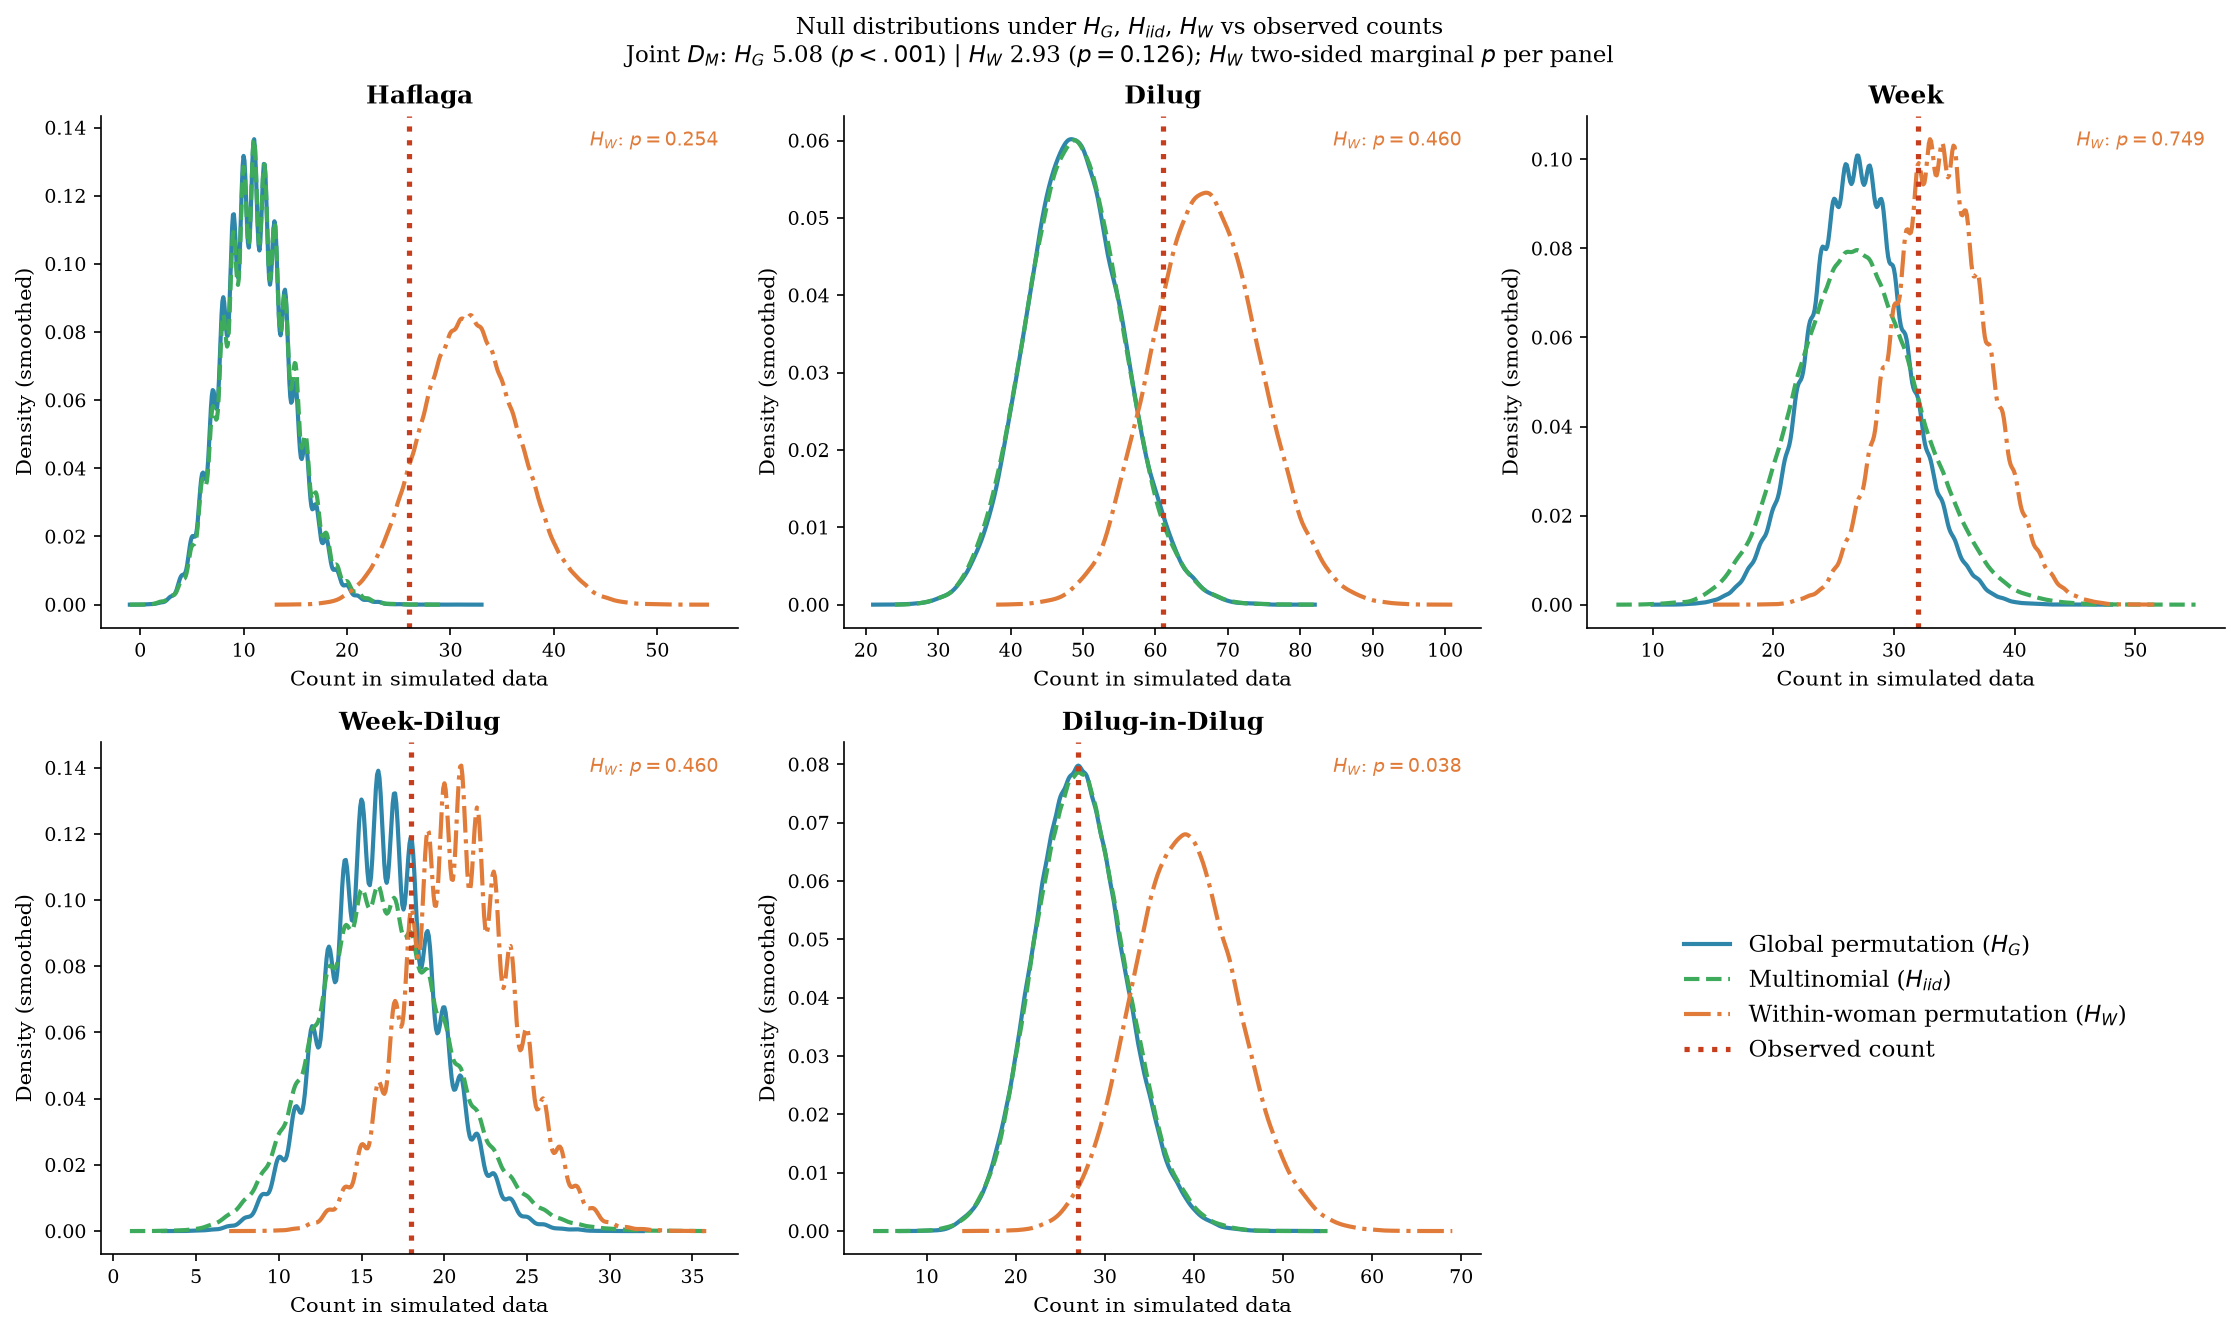

In [13]:
# fig6_stratified_comparison: all three nulls per pattern (KDE for visual comparison only) + H_W two-sided p
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()
for j, label in enumerate(PATTERN_LABELS):
    ax = axes[j]
    for arr, color, ls in [(perm_arr, C_PERM, '-'), (multi_arr, C_MULTI, '--'), (hw_arr, C_STRAT, '-.')]:
        v = arr[:, j]; kde = stats.gaussian_kde(v); xg = np.linspace(v.min()-2, v.max()+2, 400)
        ax.plot(xg, kde(xg), color=color, lw=2, ls=ls)
    ax.axvline(obs[j], color=C_OBS, lw=2.5, ls=':')
    p_hw = two_sided_p(hw_arr[:, j], obs[j])
    ax.text(0.97, 0.97, f'$H_W$: $p = {p_hw:.3f}$', transform=ax.transAxes, ha='right', va='top', fontsize=9, color=C_STRAT,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('Count in simulated data'); ax.set_ylabel('Density (smoothed)')
leg = [Line2D([0], [0], color=C_PERM, lw=2, ls='-', label='Global permutation ($H_G$)'), Line2D([0], [0], color=C_MULTI, lw=2, ls='--', label='Multinomial ($H_{iid}$)'),
       Line2D([0], [0], color=C_STRAT, lw=2, ls='-.', label='Within-woman permutation ($H_W$)'), Line2D([0], [0], color=C_OBS, lw=2.5, ls=':', label='Observed count')]
axes[5].legend(handles=leg, loc='center', fontsize=11, frameon=False); axes[5].axis('off')
fig.suptitle(f"Null distributions under $H_G$, $H_{{iid}}$, $H_W$ vs observed counts\n"
             f"Joint $D_M$: $H_G$ {joint['H_G']['DM']:.2f} ($p<.001$) | $H_W$ {joint['H_W']['DM']:.2f} ($p={joint['H_W']['p']:.3f}$); "
             f"$H_W$ two-sided marginal $p$ per panel", fontsize=11)
plt.tight_layout(); save('fig6_stratified_comparison'); plt.show()

## 5. Descriptive comparison of within-woman SD, and follow-up-length influence

Note: Haflaga is *defined* by repeated equal intervals, so a lower within-woman SD among women with a Haflaga
event is expected by construction and is reported as a descriptive characterisation, not as independent validation.

In [14]:
sd_i = np.array([H[s:f].std(ddof=1) for s, f in bounds])
a, b_ = sd_i[flags[:, 0] == 1], sd_i[flags.sum(1) == 0]
U, pU = stats.mannwhitneyu(a, b_, alternative='two-sided'); t, pt = stats.ttest_ind(a, b_, equal_var=False)
se = np.sqrt(a.var(ddof=1)/len(a) + b_.var(ddof=1)/len(b_))
dfw = se**4 / ((a.var(ddof=1)/len(a))**2/(len(a)-1) + (b_.var(ddof=1)/len(b_))**2/(len(b_)-1))
ci = (a.mean()-b_.mean()) + np.array([-1, 1])*stats.t.ppf(.975, dfw)*se
sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b_)-1)*b_.var(ddof=1))/(len(a)+len(b_)-2))
print(f'Haflaga women n={len(a)}: mean within-SD {a.mean():.2f} (between-SD {a.std(ddof=1):.2f}); no-pattern women n={len(b_)}: {b_.mean():.2f} ({b_.std(ddof=1):.2f})')
print(f'Mann-Whitney U={U:.0f} p={pU:.4f}; Welch t={t:.2f} df={dfw:.1f} p={pt:.2e}; 95% CI [{ci[0]:.2f}, {ci[1]:.2f}]; Cohen d={(a.mean()-b_.mean())/sp:.2f}')
long = n_i >= 20
print(f'Women with >=20 cycles: {long.sum()} ({n_i[long].sum()/n_i.sum()*100:.0f}% of cycles); share of events:',
      dict(zip(PATTERN_LABELS, (pw[long].sum(0)/pw.sum(0)).round(2).tolist())))
print('Spearman(n_i, events):', dict(zip(PATTERN_LABELS, [round(stats.spearmanr(n_i, pw[:, j])[0], 2) for j in range(5)])))

Haflaga women n=20: mean within-SD 1.54 (between-SD 0.59); no-pattern women n=35: 3.17 (1.75)
Mann-Whitney U=133 p=0.0002; Welch t=-5.05 df=45.5 p=7.65e-06; 95% CI [-2.29, -0.98]; Cohen d=-1.13
Women with >=20 cycles: 11 (20% of cycles); share of events: {'Haflaga': 0.35, 'Dilug': 0.21, 'Week': 0.28, 'Week-Dilug': 0.11, 'Dilug-in-Dilug': 0.3}
Spearman(n_i, events): {'Haflaga': np.float64(0.28), 'Dilug': np.float64(0.18), 'Week': np.float64(0.18), 'Week-Dilug': np.float64(0.03), 'Dilug-in-Dilug': np.float64(0.16)}


In [15]:
# Leave-one-woman-out for H_W (uses per-woman replicate counts; the aggregate null is the sum over women)
loo_pj, loo_pm = [], []
for i in range(n_w):
    o_i = obs - pw[i]; null_i = hw_arr - hw_by_woman[:, i, :]
    loo_pj.append(mahalanobis_test(null_i, o_i)[1]); loo_pm.append([two_sided_p(null_i[:, j], o_i[j]) for j in range(5)])
loo_pj, loo_pm = np.array(loo_pj), np.array(loo_pm)
print(f'LOO joint H_W p: min {loo_pj.min():.3f}, max {loo_pj.max():.3f}, #<.05: {(loo_pj<.05).sum()} of {n_w}')
print('LOO marginal p range per pattern:', {l: (round(loo_pm[:, j].min(), 3), round(loo_pm[:, j].max(), 3)) for j, l in enumerate(PATTERN_LABELS)})

LOO joint H_W p: min 0.055, max 0.224, #<.05: 0 of 118
LOO marginal p range per pattern: {'Haflaga': (np.float64(0.121), np.float64(0.387)), 'Dilug': (np.float64(0.343), np.float64(0.6)), 'Week': (np.float64(0.534), np.float64(0.93)), 'Week-Dilug': (np.float64(0.307), np.float64(0.689)), 'Dilug-in-Dilug': (np.float64(0.014), np.float64(0.073))}


## 6. Pairwise dependence (exploratory)

Rate-based Spearman correlations between per-woman event rates (events / cycles), two-sided permutation
$p$-values ($B = 50{,}000$, seed 17), Holm across the 10 pairs; binary co-occurrence robustness check.
Haflaga-30 ⊆ Week-Dilug is a deterministic property of the definitions, not an empirical finding.

In [16]:
rates = pw / n_i[:, None]
rng = np.random.default_rng(SEED); Bp = 50_000
pairs = []
for (ja, la), (jb, lb) in combinations(enumerate(PATTERN_LABELS), 2):
    rx, ry = stats.rankdata(rates[:, ja]) , stats.rankdata(rates[:, jb])
    rxc, ryc = rx - rx.mean(), ry - ry.mean(); denom = np.sqrt((rxc**2).sum()*(ryc**2).sum())
    r_obs = float(rxc @ ryc / denom)
    perms = np.array([rxc @ rng.permutation(ryc) / denom for _ in range(Bp)])
    p = (np.count_nonzero(np.abs(perms) >= abs(r_obs) - 1e-12) + 1) / (Bp + 1)
    pairs.append(dict(a=la, b=lb, r_s=r_obs, p_perm=p))
sp_df = pd.DataFrame(pairs); sp_df['p_Holm'] = holm_adjust(sp_df.p_perm.values); sp_df = sp_df.sort_values('p_perm').reset_index(drop=True)
display(sp_df.style.format({'r_s': '{:+.2f}', 'p_perm': '{:.4f}', 'p_Holm': '{:.3f}'}).set_caption('Rate-based Spearman correlations (exploratory)'))
# binary robustness
binrows = []
rng = np.random.default_rng(SEED)
for (ja, la), (jb, lb) in combinations(enumerate(PATTERN_LABELS), 2):
    x, y = flags[:, ja], flags[:, jb]
    def chi2(x, y):
        ct = np.array([[((x==0)&(y==0)).sum(), ((x==0)&(y==1)).sum()], [((x==1)&(y==0)).sum(), ((x==1)&(y==1)).sum()]])
        return stats.chi2_contingency(ct, correction=False)[0], ct
    c_obs, ct = chi2(x, y)
    perms = np.array([chi2(x, rng.permutation(y))[0] for _ in range(Bp)])
    binrows.append(dict(a=la, b=lb, chi2=c_obs, p_perm=(np.count_nonzero(perms >= c_obs - 1e-12) + 1)/(Bp+1), p_Fisher=stats.fisher_exact(ct)[1]))
bin_df = pd.DataFrame(binrows); bin_df['p_Holm'] = holm_adjust(bin_df.p_perm.values); bin_df = bin_df.sort_values('p_perm').reset_index(drop=True)
display(bin_df.head(4).style.format({'chi2': '{:.2f}', 'p_perm': '{:.4f}', 'p_Fisher': '{:.4f}', 'p_Holm': '{:.3f}'}).set_caption('Binary co-occurrence robustness check (top 4 pairs)'))

,a,b,r_s,p_perm,p_Holm
0,Haflaga,Dilug-in-Dilug,+0.27,0.0038,0.038
1,Haflaga,Week-Dilug,+0.23,0.0113,0.102
2,Dilug,Week-Dilug,-0.12,0.2059,1.000
3,Haflaga,Week,+0.10,0.2770,1.000
4,Week,Dilug-in-Dilug,+0.09,0.3262,1.000
5,Dilug,Week,+0.09,0.3374,1.000
6,Week,Week-Dilug,+0.06,0.4755,1.000
7,Week-Dilug,Dilug-in-Dilug,+0.07,0.4802,1.000
8,Haflaga,Dilug,+0.04,0.6680,1.000
9,Dilug,Dilug-in-Dilug,-0.02,0.8190,1.000


,a,b,chi2,p_perm,p_Fisher,p_Holm
0,Haflaga,Dilug-in-Dilug,9.99,0.0042,0.0038,0.042
1,Haflaga,Week-Dilug,7.26,0.0131,0.0137,0.118
2,Dilug,Week,2.40,0.1727,0.1743,1.000
3,Dilug,Week-Dilug,1.46,0.2992,0.3002,1.000


saved fig8_chisq_heatmap


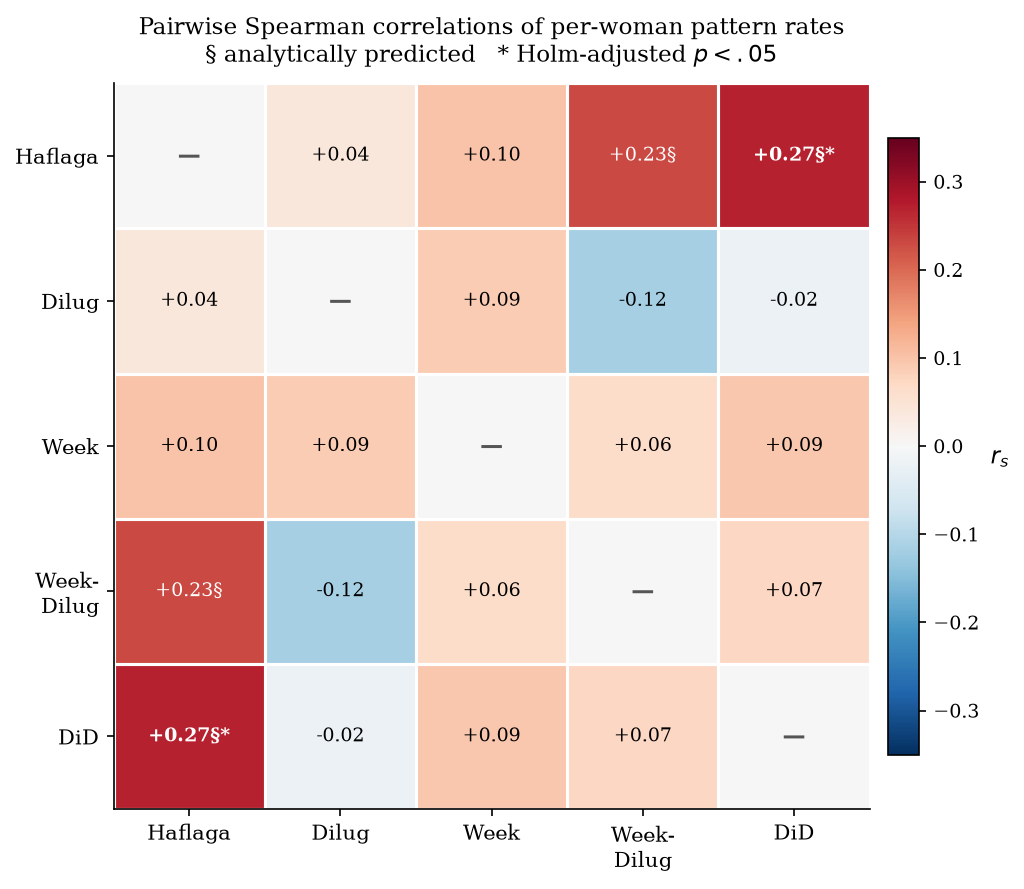

In [17]:
# fig8_chisq_heatmap: rate-based Spearman matrix; § analytically predicted pairs; * Holm p < .05
idx = {l: k for k, l in enumerate(PATTERN_LABELS)}
predicted = {('Haflaga', 'Dilug-in-Dilug'), ('Haflaga', 'Week-Dilug')}
rs_mat = np.zeros((5, 5)); holm_mat = np.ones((5, 5)); pred = np.zeros((5, 5), bool)
for _, row in sp_df.iterrows():
    i, j = idx[row.a], idx[row.b]; rs_mat[i, j] = rs_mat[j, i] = row.r_s; holm_mat[i, j] = holm_mat[j, i] = row.p_Holm
    pred[i, j] = pred[j, i] = (row.a, row.b) in predicted
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(rs_mat, cmap=plt.cm.RdBu_r, vmin=-0.35, vmax=0.35, aspect='auto')
ax_labels = ['Haflaga', 'Dilug', 'Week', 'Week-\nDilug', 'DiD']
ax.set_xticks(range(5)); ax.set_xticklabels(ax_labels, fontsize=10); ax.set_yticks(range(5)); ax.set_yticklabels(ax_labels, fontsize=10)
for k in range(6): ax.axhline(k-0.5, color='white', lw=1.5); ax.axvline(k-0.5, color='white', lw=1.5)
for i in range(5):
    for j in range(5):
        if i == j: ax.text(j, i, '—', ha='center', va='center', fontsize=11, color='#555', fontweight='bold'); continue
        lab = f'{rs_mat[i,j]:+.2f}' + ('§' if pred[i, j] else '') + ('*' if holm_mat[i, j] < .05 else '')
        ax.text(j, i, lab, ha='center', va='center', fontsize=9, color='white' if abs(rs_mat[i, j])/0.35 > 0.55 else 'black',
                fontweight='bold' if holm_mat[i, j] < .05 else 'normal')
plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02).set_label('$r_s$', fontsize=11, rotation=0, labelpad=10)
ax.set_title('Pairwise Spearman correlations of per-woman pattern rates\n§ analytically predicted   * Holm-adjusted $p < .05$', fontsize=11, pad=10)
plt.tight_layout(); save('fig8_chisq_heatmap'); plt.show()

saved fig9_joint_3panels


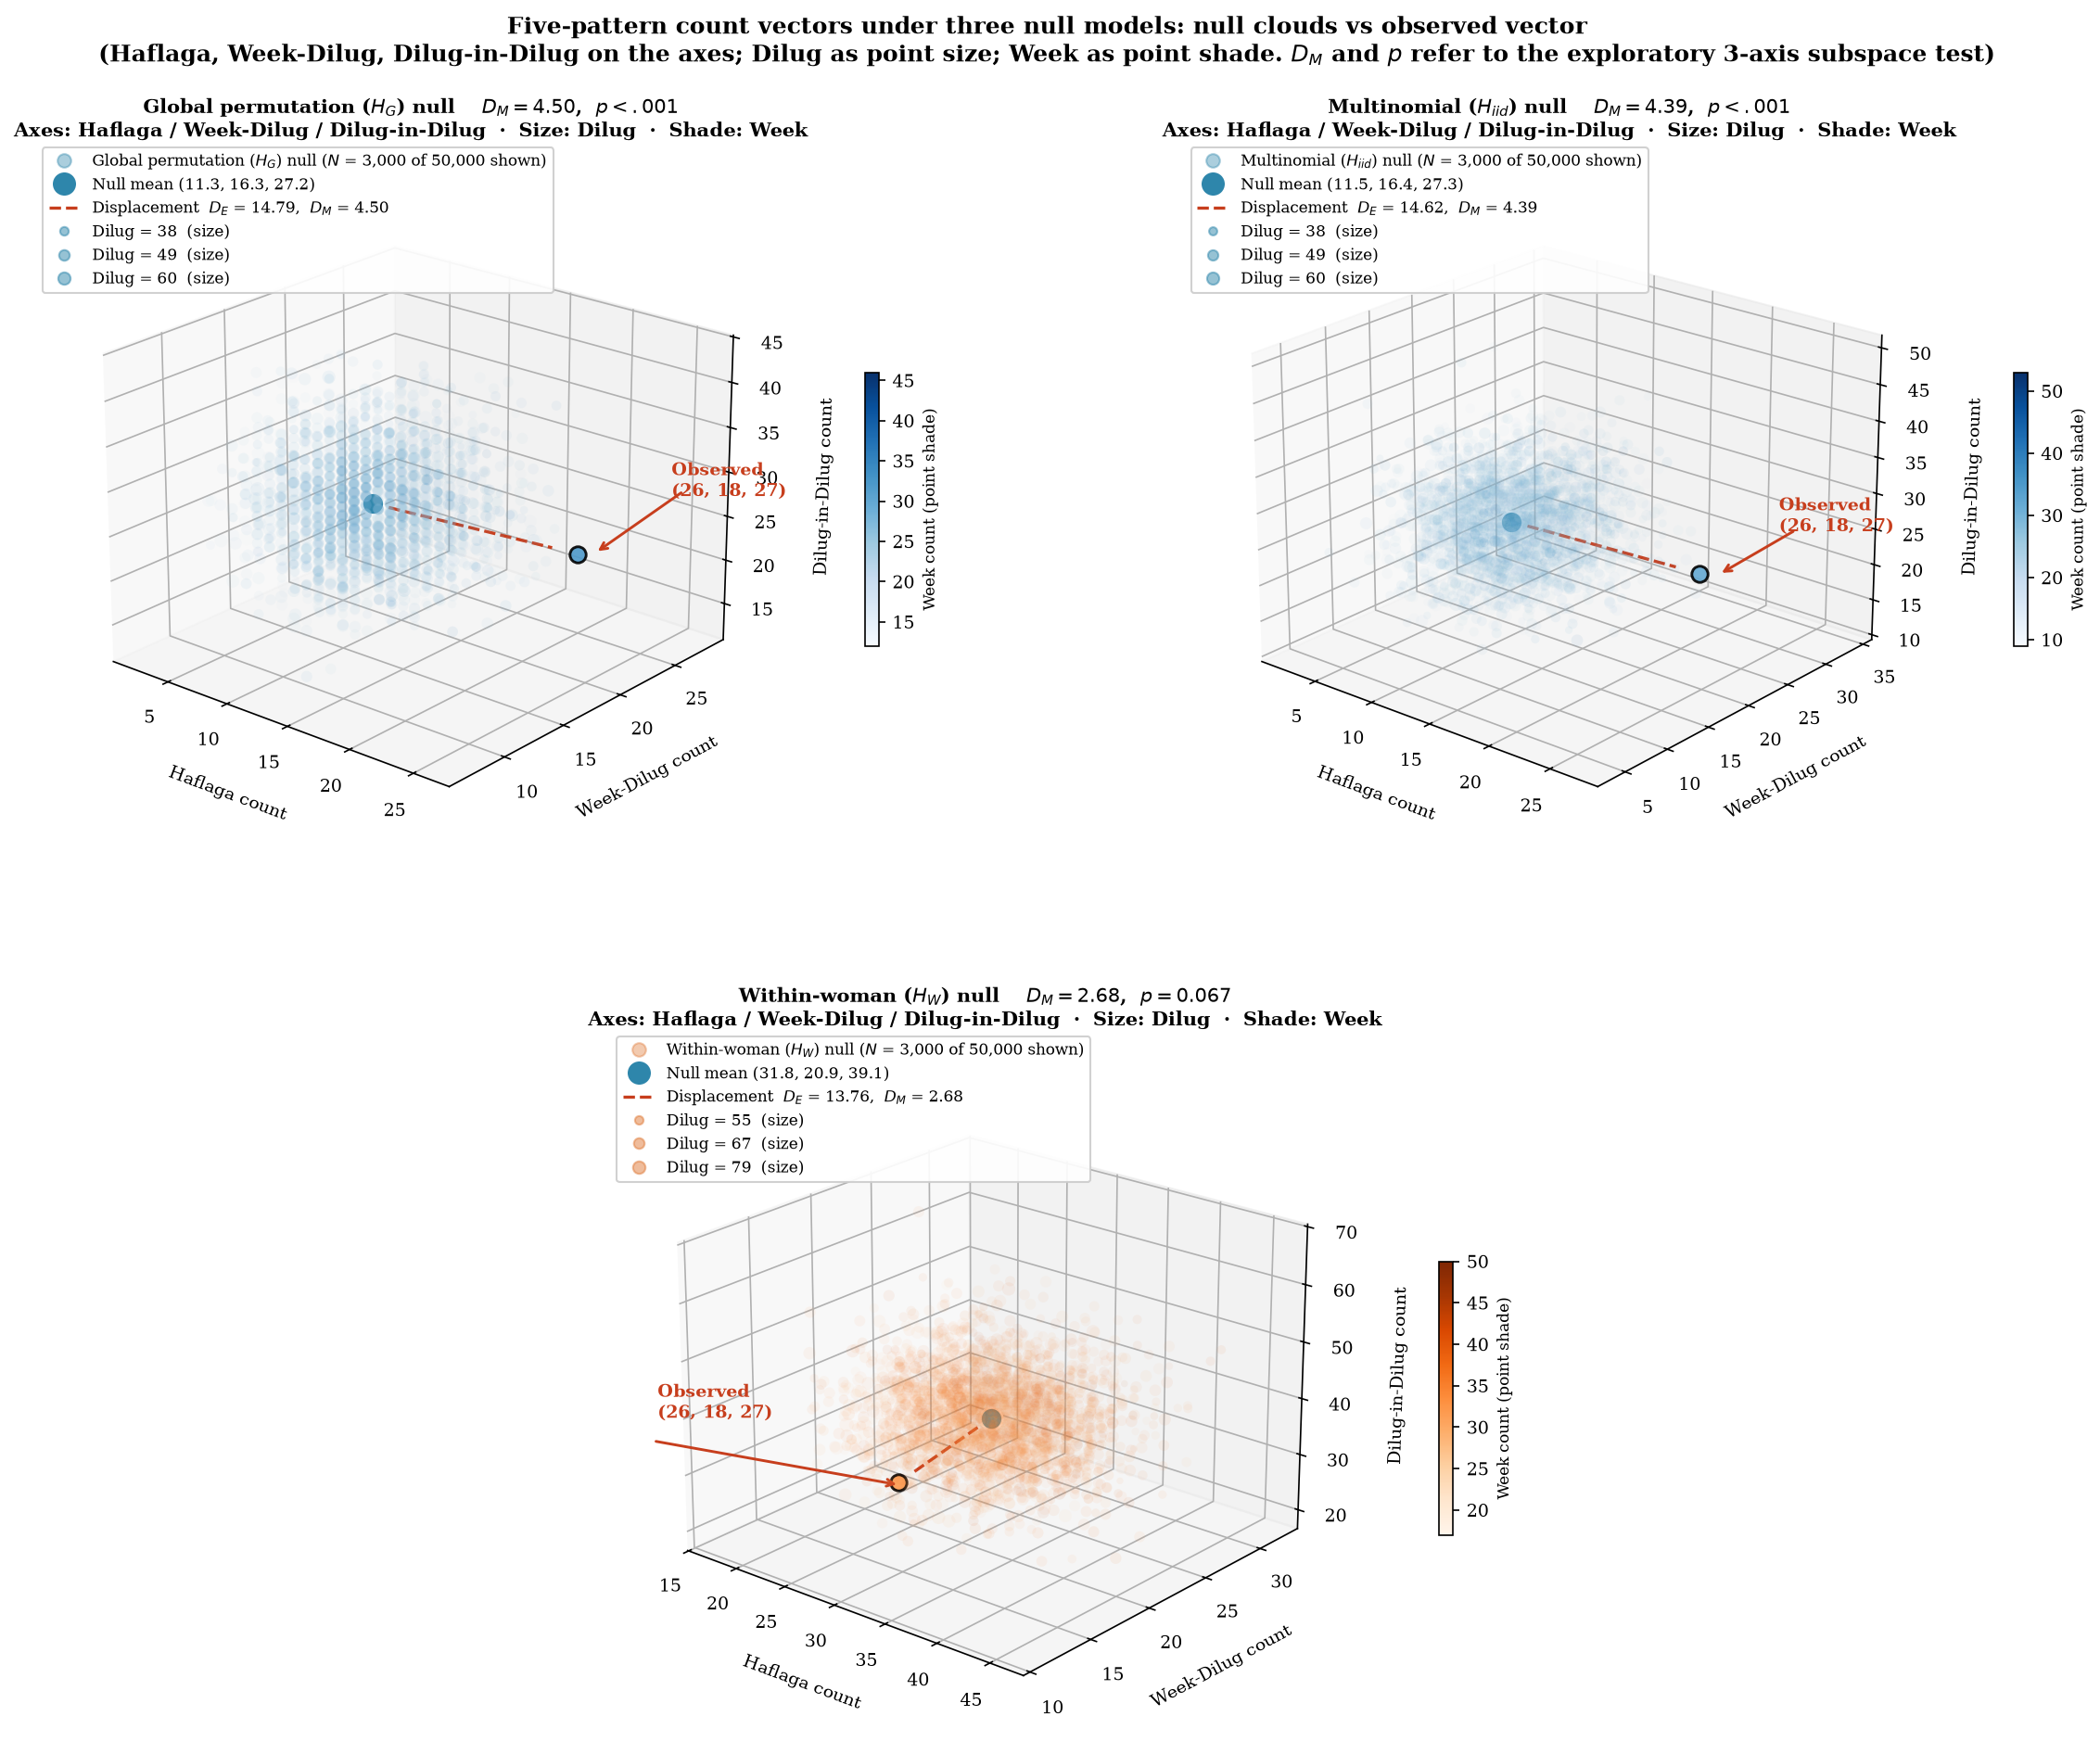

In [18]:
# fig9_joint_3panels: all five counts per replicate; Haflaga/Week-Dilug/DiD on axes, Dilug -> size, Week -> shade; D_M of the 3-axis subspace
import matplotlib.gridspec as gridspec, matplotlib.colors as mcolors
IDX3 = [0, 3, 4]; obs3 = obs[IDX3]; NS = 3000
def stats3(arr):
    sub = arr[:, IDX3]; mu = sub.mean(0); Sinv = np.linalg.inv(np.cov(sub.T)); d = obs3 - mu
    DM = float(np.sqrt(d @ Sinv @ d)); dn = sub - mu; dm = np.sqrt(np.einsum('ni,ij,nj->n', dn, Sinv, dn))
    return DM, (np.count_nonzero(dm >= DM) + 1)/(len(dm)+1), mu, float(np.linalg.norm(d))
rng = np.random.default_rng(42)
fig = plt.figure(figsize=(17, 13)); gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:2], projection='3d'); ax2 = fig.add_subplot(gs[0, 2:4], projection='3d'); ax3 = fig.add_subplot(gs[1, 1:3], projection='3d')
fig.subplots_adjust(top=0.90, bottom=0.03, left=0.02, right=0.98, hspace=0.30, wspace=0.05)
def panel(ax, arr, label, cmap, color, off):
    DM, p, mu3, DE = stats3(arr); sub = arr[:, IDX3]; idx_s = rng.choice(len(sub), NS, replace=False)
    dil = arr[:, 1]; wk = arr[:, 2]
    size_of = lambda v: 6 + 54*(v - dil.min())/(dil.max() - dil.min() + 1e-9)
    norm = mcolors.Normalize(wk.min(), wk.max())
    ax.scatter(sub[idx_s, 0], sub[idx_s, 1], sub[idx_s, 2], c=wk[idx_s], cmap=cmap, s=size_of(dil[idx_s]), alpha=0.28, linewidths=0, norm=norm)
    ax.scatter(*mu3, color=C_PERM, s=130, edgecolors='white', linewidths=1.2, zorder=10)
    u = (obs3-mu3)/(np.linalg.norm(obs3-mu3)+1e-9); e = obs3 - 1.8*u
    ax.plot([mu3[0], e[0]], [mu3[1], e[1]], [mu3[2], e[2]], color=C_OBS, lw=1.6, ls='--')
    ax.scatter(*obs3, c=[obs[2]], cmap=cmap, norm=norm, s=70, edgecolors='black', linewidths=1.4, alpha=0.95, zorder=20)
    tp = obs3 + off
    ax.text(*tp, f'Observed\n({int(obs3[0])}, {int(obs3[1])}, {int(obs3[2])})', color=C_OBS, fontsize=9, fontweight='bold', zorder=16)
    # arrow from label towards the observed point (projected 2D annotation)
    from mpl_toolkits.mplot3d import proj3d
    x0, y0, _ = proj3d.proj_transform(*obs3, ax.get_proj()); x1, y1, _ = proj3d.proj_transform(*tp, ax.get_proj())
    ax.annotate('', xy=(x0, y0), xytext=(x1, y1), xycoords='data', textcoords='data',
                arrowprops=dict(arrowstyle='->', color=C_OBS, lw=1.4))
    q = np.percentile(dil, [5, 50, 95]).round().astype(int)
    handles = [Line2D([0], [0], marker='o', ls='', color=color, alpha=0.4, markersize=7, label=f'{label} null ($N$ = {NS:,} of {len(arr):,} shown)'),
               Line2D([0], [0], marker='o', ls='', color=C_PERM, markersize=11, label=f'Null mean ({mu3[0]:.1f}, {mu3[1]:.1f}, {mu3[2]:.1f})'),
               Line2D([0], [0], color=C_OBS, ls='--', lw=1.6, label=f'Displacement  $D_E$ = {DE:.2f},  $D_M$ = {DM:.2f}')]
    handles += [Line2D([0], [0], marker='o', ls='', color=color, alpha=0.5, markersize=np.sqrt(size_of(v)), label=f'Dilug = {v}  (size)') for v in q]
    ax.legend(handles=handles, loc='upper left', fontsize=8, bbox_to_anchor=(-0.05, 1.04), framealpha=0.9)
    ax.set_xlabel('Haflaga count', labelpad=8, fontsize=9); ax.set_ylabel('Week-Dilug count', labelpad=8, fontsize=9); ax.set_zlabel('Dilug-in-Dilug count', labelpad=8, fontsize=9)
    p_str = '$p < .001$' if p < .001 else f'$p = {p:.3f}$'
    ax.set_title(f'{label} null    $D_M = {DM:.2f}$,  {p_str}\nAxes: Haflaga / Week-Dilug / Dilug-in-Dilug  ·  Size: Dilug  ·  Shade: Week', fontsize=10, fontweight='bold', pad=16)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([]); fig.colorbar(sm, ax=ax, shrink=0.40, pad=0.10).set_label('Week count (point shade)', fontsize=8)
    ax.view_init(elev=22, azim=-50)
panel(ax1, perm_arr, 'Global permutation ($H_G$)', 'Blues', C_PERM, np.array([4., 3.5, 6.]))
panel(ax2, multi_arr, 'Multinomial ($H_{iid}$)', 'Blues', C_PERM, np.array([4., 3.5, 6.]))
panel(ax3, hw_arr, 'Within-woman ($H_W$)', 'Oranges', C_STRAT, np.array([-16., -7., 9.]))
fig.suptitle('Five-pattern count vectors under three null models: null clouds vs observed vector\n'
             '(Haflaga, Week-Dilug, Dilug-in-Dilug on the axes; Dilug as point size; Week as point shade. '
             '$D_M$ and $p$ refer to the exploratory 3-axis subspace test)', fontsize=12, fontweight='bold', y=0.985)
save('fig9_joint_3panels'); plt.show()

## 7. Simulation validation (size, power, sensitivity)

Produced by `scripts/sim_validation.py`:

* **Part A** — empirical size of the marginal, Holm-family and joint tests under each null using fresh
  pseudo-observed datasets; joint test evaluated with plug-in (same batch for $\hat\Sigma$ and reference)
  and split-batch procedures.
* **Part B** — power of the $H_W$ tests against within-woman AR(1) alternatives (each woman's own mean and SD,
  rounded to days) and "persistence" alternatives (each cycle repeats the previous haflaga exactly with
  probability $q$). Each simulated dataset is analysed with its own 2,000 within-woman permutations.
* **Part C** — $H_W$ analysis after truncating every woman to her first 12 cycles.

Part A (B_ref=20,000, fresh datasets=10,000); nominal alpha = .05
 null  marg_Haflaga  marg_Dilug  marg_Week  marg_Week-Dilug  marg_Dilug-in-Dilug  Holm_FWER  joint_plugin  joint_split  joint_plugin_01  joint_split_01
  H_G         0.029       0.047      0.034            0.031                0.046      0.033         0.048        0.052           0.0110          0.0097
H_iid         0.048       0.038      0.040            0.038                0.046      0.032         0.049        0.047           0.0072          0.0074
  H_W         0.043       0.041      0.043            0.042                0.040      0.037         0.053        0.053           0.0087          0.0096

Part B (R=400 datasets per scenario, B_in=2,000); power of H_W tests at alpha=.05
 family  level  mean_obs_Haflaga  mean_nullmean_Haflaga  pow_Haflaga  pow_Dilug  pow_Week  pow_Week-Dilug  pow_Dilug-in-Dilug  Holm_any  joint
    ar1   0.00              30.0                   30.1         0.04       0.04      0.04           

saved fig10_power


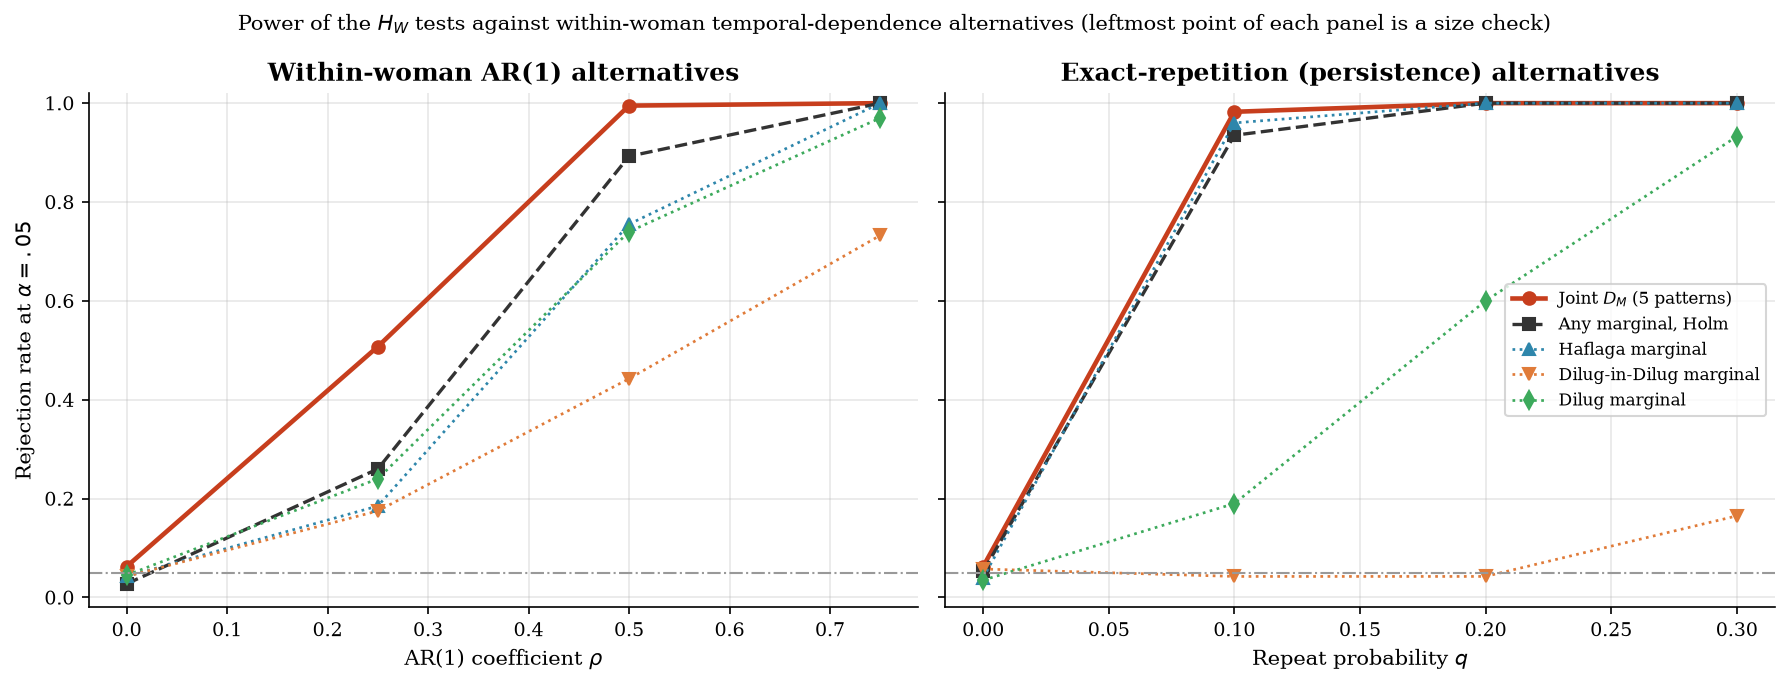

In [19]:
SV = '../results/sim_validation.npz'
if os.path.exists(SV):
    S = np.load(SV, allow_pickle=True)
    A, Bres, Cres = list(S['part_a']), list(S['part_b']), S['part_c'][0]
    print(f"Part A (B_ref={int(S['B_REF']):,}, fresh datasets={int(S['N_FRESH']):,}); nominal alpha = .05")
    print(pd.DataFrame([dict(null='H_'+r['null'], **{f'marg_{l}': round(r['marg_rate'][j], 3) for j, l in enumerate(PATTERN_LABELS)},
                              Holm_FWER=round(r['holm_fwer'], 3), joint_plugin=round(r['joint_plug_05'], 3), joint_split=round(r['joint_split_05'], 3),
                              joint_plugin_01=round(r['joint_plug_01'], 4), joint_split_01=round(r['joint_split_01'], 4)) for r in A]).to_string(index=False))
    print(f"\nPart B (R={int(S['R_ALT'])} datasets per scenario, B_in={int(S['B_IN']):,}); power of H_W tests at alpha=.05")
    tabB = pd.DataFrame([dict(family=r['family'], level=r['level'], mean_obs_Haflaga=round(r['obs_mean'][0], 1), mean_nullmean_Haflaga=round(r['null_mean'][0], 1),
                              **{f'pow_{l}': round(r['marg_power'][j], 2) for j, l in enumerate(PATTERN_LABELS)},
                              Holm_any=round(r['holm_power'], 2), joint=round(r['joint_power'], 2)) for r in Bres])
    print(tabB.to_string(index=False))
    print(f"\nPart C: first 12 cycles per woman ({int(Cres['n_cycles'])} cycles): obs {Cres['obs'].astype(int)}, H_W mean {Cres['mu'].round(2)}, z {Cres['z'].round(2)}, "
          f"p {Cres['p'].round(3)}, D_M {Cres['DM']:.2f} p {Cres['pj']:.3f}")
    # fig10_power
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
    for ax, fam, xl in [(axes[0], 'ar1', 'AR(1) coefficient $\\rho$'), (axes[1], 'persist', 'Repeat probability $q$')]:
        rs = sorted([r for r in Bres if r['family'] == fam], key=lambda r: r['level']); xs = [r['level'] for r in rs]
        ax.plot(xs, [r['joint_power'] for r in rs], 'o-', color=C_OBS, lw=2.2, label='Joint $D_M$ (5 patterns)')
        ax.plot(xs, [r['holm_power'] for r in rs], 's--', color='#333', lw=1.6, label='Any marginal, Holm')
        for j, (l, c, m) in enumerate([('Haflaga', C_PERM, '^'), ('Dilug-in-Dilug', C_STRAT, 'v'), ('Dilug', C_MULTI, 'd')]):
            jj = PATTERN_LABELS.index(l); ax.plot(xs, [r['marg_power'][jj] for r in rs], m+':', color=c, lw=1.3, label=f'{l} marginal')
        ax.axhline(0.05, color='#999', lw=1, ls='-.'); ax.set_xlabel(xl); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.3)
    axes[0].set_ylabel('Rejection rate at $\\alpha = .05$'); axes[0].set_title('Within-woman AR(1) alternatives', fontweight='bold')
    axes[1].set_title('Exact-repetition (persistence) alternatives', fontweight='bold'); axes[1].legend(fontsize=8, loc='center right')
    fig.suptitle('Power of the $H_W$ tests against within-woman temporal-dependence alternatives (leftmost point of each panel is a size check)', fontsize=10)
    plt.tight_layout(); save('fig10_power'); plt.show()
else:
    print('results/sim_validation.npz not found — run scripts/sim_validation.py')